# Intersectional Fairness in Machine Learning An Analysis Using Oxonfair.
## Reproduction Notebook — Dylan Thompson, TCD MSc Computer Science 2025

**Supervisor:** Eoin Delaney

This notebook reproduces all experimental results, tables, and figures reported in the dissertation

**How to run:** `Kernel → Restart & Run All`

Set `RUN_ALL = True` (Cell 2) to re-run full experiments (~3–4 hrs).
Set `RUN_ALL = False` (default) to load cached results from `results/` and regenerate figures only (~2 min).

| Notebook Section | Dissertation Chapter / Section |
|---|---|
| 0 — Setup | — |
| 1 — Data Loading | Ch. 4: Datasets and Methodology, Table 4.1 |
| 2 — Baseline | Section 5.1: Baseline Intersectional Audit Gap, Table 5.1, Figure 5.1 |
| 3 — Oversampling | Section 5.2: Pre-Processing, Table 5.2, Appendix (oversampling figures) |
| 4 — ExponentiatedGradient | Section 5.5: In-Processing, Table 5.6, Figure 5.3, Appendix (EG grid) |
| 5 — OxonFair Post-Processing | Section 5.3: Post-Processing, Table 5.3, Figure 5.2, Appendix (EOD table) |
| 6 — Impossibility Theorem | Section 5.4: Metric Conflict, Tables 5.4–5.5, Appendix (base rates) |
| 7 — Figures | All dissertation figures (saved to figures/) |
| 8 — Three-Attribute Extension | Section 5.6: Scalability, Table 5.7, Appendix (8-group TPR figure) |


---
## Section 0 — Setup

Install dependencies and import libraries. All package versions are pinned in `requirements.txt`
to ensure full reproducibility (Section 4.2, fixed random seed = 42 throughout).


In [1]:
# Install all dependencies (pinned versions — see requirements.txt)
# !pip install lightgbm==4.6.0 fairlearn==0.13.0 oxonfair==0.2.1.11 \
#              scikit-learn==1.7.2 pandas==2.3.3 numpy==2.1.3 \
#              matplotlib==3.10.7 folktables==0.0.12 xgboost==3.1.1


In [2]:
import warnings
warnings.filterwarnings('ignore')

import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from pathlib import Path
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.metrics import accuracy_score, f1_score
import xgboost as xgb
from lightgbm import LGBMClassifier
from fairlearn.reductions import ExponentiatedGradient, TruePositiveRateParity
from oxonfair import FairPredictor, dataset_loader
from oxonfair import group_metrics as gm
from folktables import ACSDataSource, ACSIncome, ACSPublicCoverage, ACSTravelTime

RANDOM_SEED = 42
RUN_ALL = False  # Set True to retrain from scratch False loads cached results
RESULTS_DIR = Path('results')
DATA_DIR = Path('data')
FIGURES_DIR = Path('figures')
RESULTS_DIR.mkdir(exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

# Epsilon grid for ExponentiatedGradient hyperparameter selection (Section 5.5)
# Six ε values spanning tight to loose TPR-parity budgets (Section 4.3).
# Selected to cover the range used in the fairlearn literature;
# ε* chosen per dataset on the validation set (Shaham et al. 2025).
# ε grid: six values spanning tight (0.01) to loose (0.30) TPR-parity budgets (Section 4.3).
# ε* is selected per dataset on the val set — never touching the test set
EG_EPS_GRID = [0.01, 0.03, 0.05, 0.10, 0.15, 0.30]
print('Setup OK')


Setup OK


In [3]:
# Fairness metric functions — definitions match Section 3.2 and Table 3.1 in the dissertation.
# All metrics follow the convention: lower = fairer, 0 = perfect parity.

def mean_if_nonempty(values):
    """Return the mean of an array, or NaN if it is empty."""
    return float(np.mean(values)) if len(values) else float('nan')

def max_gap_across_groups(tpr_by_group):
    """Return the max minus min across group TPRs, ignoring NaN entries."""
    valid_tprs = [t for t in tpr_by_group.values() if not np.isnan(t)]
    return float(max(valid_tprs) - min(valid_tprs)) if len(valid_tprs) >= 2 else 0.0

def tpr_per_group(y_true, y_pred, group_labels):
    """True positive rate for each group: TP / (TP + FN)."""
    return {
        str(group): mean_if_nonempty(y_pred[(group_labels == group) & (y_true == 1)])
        for group in np.unique(group_labels)
    }

def fpr_per_group(y_true, y_pred, group_labels):
    """False positive rate for each group: FP / (FP + TN)."""
    return {
        str(group): mean_if_nonempty(y_pred[(group_labels == group) & (y_true == 0)])
        for group in np.unique(group_labels)
    }

def selection_rate_per_group(y_pred, group_labels):
    """Positive prediction rate for each group (used for demographic parity, Section 3.2)."""
    return {
        str(group): mean_if_nonempty(y_pred[group_labels == group])
        for group in np.unique(group_labels)
    }

def compute_metrics(y_true, y_pred, single_attr_groups, intersect_groups):
    """Compute all fairness and accuracy metrics for one classifier-dataset pair.

    Returns a dict with keys used throughout this notebook:
      dEO = ΔEO  (single-attribute equal opportunity difference)
      dEOi = ΔEO∩ (intersectional equal opportunity difference) — primary metric
      dEODi = ΔEOD∩ (intersectional equalised odds difference)
      dDP = ΔDP  (single-attribute demographic parity gap)
      dDPi = ΔDP∩ (intersectional demographic parity gap)
    """
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)

    delta_eoi = round(max_gap_across_groups(tpr_per_group(y_true, y_pred, intersect_groups)), 4)
    delta_fpri = round(max_gap_across_groups(fpr_per_group(y_true, y_pred, intersect_groups)), 4)

    return {
        'Acc': round(accuracy_score(y_true, y_pred), 4),
        'F1': round(f1_score(y_true, y_pred, zero_division=0), 4),
        'dEO': round(max_gap_across_groups(tpr_per_group(y_true, y_pred, single_attr_groups)), 4),
        'dDP': round(max_gap_across_groups(selection_rate_per_group(y_pred, single_attr_groups)), 4),
        'dDPi': round(max_gap_across_groups(selection_rate_per_group(y_pred, intersect_groups)), 4),
        'dEOi': delta_eoi,
        'dFPRi': delta_fpri,
        'dEODi': round(max(delta_eoi, delta_fpri), 4),
    }

def predict_binary(model, features):
    """Return hard binary predictions from a model's probability output (threshold 0.5)."""
    probabilities = model.predict_proba(features)
    if hasattr(probabilities, 'values'):
        probabilities = probabilities.values
    return (probabilities[:, 1] >= 0.5).astype(int)


---
## Section 1 — Data Loading

Loads all ten benchmark datasets described in **Ch. 4 (Table 4.1)**.

Each dataset is paired with two binary protected attributes, yielding **four intersectional subgroups**
via Cartesian product (Section 4.1, Eq. 2). Splits are stratified 75/25 outer (train+val / test) and
75/25 inner (train / val), with random seed 42 (Section 4.2).

| Dataset | Protected attributes | Intersectional subgroups |
|---|---|---|
| Adult Income | Sex × Age (>50) | F≤50, F>50, M≤50, M>50 |
| COMPAS | Race × Sex | AfAm-F, AfAm-M, Other-F, Other-M |
| ACS Travel Time | Race × Sex | F-NW, F-W, M-NW, M-W |
| Bank Marketing | Age (>40) × Marital | ≤40-Mar, ≤40-NMar, >40-Mar, >40-NMar |
| Taiwan Default | Sex × Education | F-HiEdu, F-LoEdu, M-HiEdu, M-LoEdu |
| Diabetes Indicators | Sex × Age (≥50) | F-50+, F-<50, M-50+, M-<50 |
| SUPPORT2 | Race × Sex | NW-F, NW-M, W-F, W-M |
| ACS Public Coverage | Sex × Age (>35) | F-≤35, F->35, M-≤35, M->35 |
| ACS Income | Sex × Age (>35) | F-≤35, F->35, M-≤35, M->35 |
| Law School (LSAC) | Race × Sex | NW-F, NW-M, W-F, W-M |

ACS datasets are downloaded automatically via `folktables` on first run (internet required).
All others load via OxonFair's built-in loader.


In [4]:
# GROUP_COLUMNS are appended to each split so OxonFair can look up group membership.
# ModelWrapper strips them before calling the underlying classifier.
GROUP_COLUMNS = ['__g_single__', '__g_intersect__']


# ModelWrapper adapts any sklearn-style classifier to OxonFair's FairPredictor API.
# FairPredictor expects the protected group column to live inside the DataFrame it
# receives, so ModelWrapper strips GROUP_COLUMNS before calling the underlying
# classifier — keeping evaluation code clean.
class ModelWrapper:
    # Wraps a classifier, stripping group columns before predict/predict_proba
    def __init__(self, base_model):
        self.base_model = base_model

    def strip_group_columns(self, X):
        if hasattr(X, 'drop'):
            return X.drop(columns=[c for c in GROUP_COLUMNS if c in X.columns])
        return X

    def predict(self, X):
        return self.base_model.predict(self.strip_group_columns(X))

    def predict_proba(self, X):
        return self.base_model.predict_proba(self.strip_group_columns(X))

    def __getattr__(self, attr):
        if attr == 'base_model':
            raise AttributeError(attr)
        return getattr(self.base_model, attr)


def encode_groups_as_integers(group_labels):
    # Encode string group labels as integers, consistently across all splits
    label_to_int = {g: i for i, g in enumerate(sorted(np.unique(group_labels)))}
    return np.array([label_to_int[g] for g in group_labels], dtype=int), label_to_int


def make_splits(features, labels, single_attr_groups, intersect_groups, seed=RANDOM_SEED):
    # 75/25 outer split (train+val / test), then 75/25 inner (train / val).
    # Matches the leakage-free protocol in section 4.1. Test set used exactly once.
    all_idx = np.arange(len(labels))
    # 75/25 outer split — test set held out until final evaluation, used exactly once (Section 4.1)
    trainval_idx, test_idx = train_test_split(all_idx, test_size=0.25, random_state=seed, stratify=labels)
    # 75/25 inner split — val used only for threshold/ε selection, never for final metrics (Section 4.1)
    train_idx, val_idx = train_test_split(trainval_idx, test_size=0.25, random_state=seed, stratify=labels[trainval_idx])
    group_int_labels, _ = encode_groups_as_integers(intersect_groups)

    def pack(idx):
        df = features.iloc[idx].reset_index(drop=True) if hasattr(features, 'iloc') else pd.DataFrame(features[idx])
        df['__g_single__'] = single_attr_groups[idx].astype(int)
        df['__g_intersect__'] = group_int_labels[idx]
        return {'data': df, 'target': labels[idx], 'y': labels[idx],
                'g_single': single_attr_groups[idx], 'g_intersect': intersect_groups[idx]}

    return pack(train_idx), pack(val_idx), pack(test_idx)


def get_features(split):
    # Returns the feature matrix with group helper columns dropped
    return split['data'].drop(columns=[c for c in GROUP_COLUMNS if c in split['data'].columns])


# Dataset loaders - each returns (train, val, test) dicts.
# Protected attributes are binarised as in Table 4.1.
def load_adult():
    train, val, test = dataset_loader.adult('sex', seed=RANDOM_SEED)
    for s in [train, val, test]:
        is_male = s['data']['sex'].values.astype(int)
        is_older = (s['data']['age'].values > 33).astype(int)
        groups = [f'{"Male" if m else "Female"}_{"Age>50" if a else "Age<=50"}'
                  for m, a in zip(is_male, is_older)]
        s['g_single'] = is_male
        s['g_intersect'] = np.array(groups)
        s['y'] = np.asarray(s['target'], dtype=int)
        s['data']['__g_single__'] = is_male
    _, lmap = encode_groups_as_integers(np.concatenate([s['g_intersect'] for s in [train, val, test]]))
    for s in [train, val, test]:
        s['data']['__g_intersect__'] = np.array([lmap[g] for g in s['g_intersect']], dtype=int)
    return train, val, test


def load_compas():
    train, val, test = dataset_loader.compas(seed=RANDOM_SEED)
    for s in [train, val, test]:
        is_african_american = (s['data']['race'].values.astype(int) == 0).astype(int)
        is_male = s['data']['sex'].values.astype(int)
        groups = [f'{"AfAm" if r else "Other"}_{"Male" if m else "Female"}'
                  for r, m in zip(is_african_american, is_male)]
        s['g_single'] = is_african_american
        s['g_intersect'] = np.array(groups)
        s['y'] = np.asarray(s['target'], dtype=int)
        s['data']['__g_single__'] = is_african_american
    _, lmap = encode_groups_as_integers(np.concatenate([s['g_intersect'] for s in [train, val, test]]))
    for s in [train, val, test]:
        s['data']['__g_intersect__'] = np.array([lmap[g] for g in s['g_intersect']], dtype=int)
    return train, val, test


def load_bank_marketing():
    train, val, test = dataset_loader.bank_marketing(seed=RANDOM_SEED)
    for s in [train, val, test]:
        is_older = (s['data']['age'].values > 22).astype(int)
        is_married = (s['data']['marital'].values == 1).astype(int)
        groups = [f'{"Age>40" if a else "Age<=40"}_{"Married" if m else "NotMarried"}'
                  for a, m in zip(is_older, is_married)]
        s['g_single'] = is_older
        s['g_intersect'] = np.array(groups)
        s['y'] = np.asarray(s['target'], dtype=int)
        s['data']['__g_single__'] = is_older
    _, lmap = encode_groups_as_integers(np.concatenate([s['g_intersect'] for s in [train, val, test]]))
    for s in [train, val, test]:
        s['data']['__g_intersect__'] = np.array([lmap[g] for g in s['g_intersect']], dtype=int)
    return train, val, test


def load_taiwan_default():
    train, val, test = dataset_loader.taiwan_default(seed=RANDOM_SEED)
    for s in [train, val, test]:
        is_male = s['data']['sex'].values.astype(int)
        is_high_edu = (s['data']['education'].values <= 2).astype(int)
        groups = [f'{"Male" if m == 0 else "Female"}_{"HighEdu" if e else "LowEdu"}'
                  for m, e in zip(is_male, is_high_edu)]
        s['g_single'] = is_male
        s['g_intersect'] = np.array(groups)
        s['y'] = np.asarray(s['target'], dtype=int)
        s['data']['__g_single__'] = is_male
    _, lmap = encode_groups_as_integers(np.concatenate([s['g_intersect'] for s in [train, val, test]]))
    for s in [train, val, test]:
        s['data']['__g_intersect__'] = np.array([lmap[g] for g in s['g_intersect']], dtype=int)
    return train, val, test


def load_diabetes():
    train, val, test = dataset_loader.diabetes(seed=RANDOM_SEED)
    for s in [train, val, test]:
        is_male = s['data']['Sex'].values.astype(int)
        is_older = (s['data']['Age'].values >= 6).astype(int)
        groups = [f'{"Male" if m else "Female"}_{"Age50+" if a else "Age<50"}'
                  for m, a in zip(is_male, is_older)]
        s['g_single'] = is_male
        s['g_intersect'] = np.array(groups)
        s['y'] = np.asarray(s['target'], dtype=int)
        s['data']['__g_single__'] = is_male
    _, lmap = encode_groups_as_integers(np.concatenate([s['g_intersect'] for s in [train, val, test]]))
    for s in [train, val, test]:
        s['data']['__g_intersect__'] = np.array([lmap[g] for g in s['g_intersect']], dtype=int)
    return train, val, test


def load_support2():
    train, val, test = dataset_loader.support2(seed=RANDOM_SEED)
    for s in [train, val, test]:
        is_white = (s['data']['race'].values == 4).astype(int)
        is_male = s['data']['sex'].values.astype(int)
        groups = [f'{"White" if r else "NonWhite"}_{"Male" if m else "Female"}'
                  for r, m in zip(is_white, is_male)]
        s['g_single'] = is_white
        s['g_intersect'] = np.array(groups)
        s['y'] = np.asarray(s['target'], dtype=int)
        s['data']['__g_single__'] = is_white
    _, lmap = encode_groups_as_integers(np.concatenate([s['g_intersect'] for s in [train, val, test]]))
    for s in [train, val, test]:
        s['data']['__g_intersect__'] = np.array([lmap[g] for g in s['g_intersect']], dtype=int)
    return train, val, test


print('Loading ACS PUMS 2018 California (downloads on first run)...')
acs_source = ACSDataSource(survey_year='2018', horizon='1-Year', survey='person')
acs_raw = acs_source.get_data(states=['CA'], download=True)
print('ACS data ready.')


def load_acs_traveltime():
    arr, labels, _ = ACSTravelTime.df_to_numpy(acs_raw)
    df = pd.DataFrame(arr, columns=ACSTravelTime.features)
    is_male = (df['SEX'].values   == 1).astype(int)
    is_white = (df['RAC1P'].values == 1).astype(int)
    groups = [f'{"Male" if m else "Female"}_{"White" if r else "NonWhite"}'
              for m, r in zip(is_male, is_white)]
    return make_splits(df.drop(columns=['SEX', 'RAC1P']), labels.astype(int), is_male, np.array(groups))


def load_acs_public_coverage():
    arr, labels, _ = ACSPublicCoverage.df_to_numpy(acs_raw)
    df = pd.DataFrame(arr, columns=ACSPublicCoverage.features)
    is_male = (df['SEX'].values  == 1).astype(int)
    is_older = (df['AGEP'].values > 35).astype(int)
    groups = [f'{"Male" if m else "Female"}_{"Age>35" if a else "Age<=35"}'
              for m, a in zip(is_male, is_older)]
    return make_splits(df, labels.astype(int), is_male, np.array(groups))


def load_acs_income():
    arr, labels, _ = ACSIncome.df_to_numpy(acs_raw)
    df = pd.DataFrame(arr, columns=ACSIncome.features)
    is_male = (df['SEX'].values  == 1).astype(int)
    is_older = (df['AGEP'].values > 35).astype(int)
    groups = [f'{"Male" if m else "Female"}_{"Age>35" if a else "Age<=35"}'
              for m, a in zip(is_male, is_older)]
    return make_splits(df, labels.astype(int), is_male, np.array(groups))


def load_law_school():
    law_path = DATA_DIR / 'law_school_clean.csv'
    if not law_path.exists():
        url = ('https://raw.githubusercontent.com/tailequy/fairness_dataset'
               '/main/experiments/data/law_school_clean.csv')
        urllib.request.urlretrieve(url, law_path)
        print(f'Downloaded -> {law_path}')
    df = pd.read_csv(law_path).dropna()
    labels = df['pass_bar'].astype(int).values
    feature_cols = ['decile1b', 'decile3', 'lsat', 'ugpa', 'zfygpa', 'zgpa', 'fulltime', 'fam_inc', 'tier']
    is_white = (df['race'].values == 'White').astype(int)
    is_male = df['male'].values.astype(int)
    groups = [f'{"White" if r else "NonWhite"}_{"Male" if m else "Female"}'
              for r, m in zip(is_white, is_male)]
    return make_splits(df[feature_cols], labels, is_white, np.array(groups))


print('All data loaders defined.')


Loading ACS PUMS 2018 California (downloads on first run)...
ACS data ready.
All data loaders defined.


In [5]:
# Load all 10 datasets
print('Loading datasets...')
DATASETS = [
    ('adult_income','Adult Income',load_adult),
    ('compas','COMPAS', load_compas),
    ('acs_traveltime','ACS Travel Time (CA 2018)',load_acs_traveltime),
    ('bank_marketing','Bank Marketing', load_bank_marketing),
    ('taiwan_default','Taiwan Default', load_taiwan_default),
    ('diabetes','Diabetes Indicators', load_diabetes),
    ('support2','SUPPORT2',load_support2),
    ('acs_public_coverage','ACS Pub. Cov. (CA 2018)',load_acs_public_coverage),
    ('acs_income','ACS Income (CA 2018)',load_acs_income),
    ('law_school','Law School (LSAC)',load_law_school),
]
splits = {}
for key, name, loader in DATASETS:
    train_split, val_split, test_split = loader()
    splits[key] = (train_split, val_split, test_split)
    print(f'  {name:<30} train={len(train_split["y"]):>7,}  val={len(val_split["y"]):>6,}  test={len(test_split["y"]):>6,}')
print('All datasets loaded.')


Loading datasets...
  Adult Income                   train= 24,421  val=12,210  test=12,211
  COMPAS                         train=  3,606  val= 1,805  test= 1,803
  ACS Travel Time (CA 2018)      train= 97,035  val=32,346  test=43,127
  Bank Marketing                 train= 22,606  val=11,301  test=11,304
  Taiwan Default                 train= 15,000  val= 7,500  test= 7,500
  Diabetes Indicators            train=126,842  val=63,417  test=63,421
  SUPPORT2                       train=  4,553  val= 2,275  test= 2,277
  ACS Pub. Cov. (CA 2018)        train= 77,936  val=25,979  test=34,639
  ACS Income (CA 2018)           train=110,061  val=36,687  test=48,917
  Law School (LSAC)              train= 11,698  val= 3,900  test= 5,200
All datasets loaded.


In [6]:
# Appendix B — Group counts and base rates (generates Table 1 data)
print(f"{'Dataset':<30} {'Group':<25} {'n_test':>7} {'base_rate':>10}")
print('-' * 75)
for key, name, _ in DATASETS:
    _, _, test_split = splits[key]
    for g in sorted(np.unique(test_split['g_intersect'])):
        mask = test_split['g_intersect'] == g
        print(f'{name:<30} {g:<25} {mask.sum():>7,} {test_split["y"][mask].mean():>10.3f}')
    print()


Dataset                        Group                      n_test  base_rate
---------------------------------------------------------------------------
Adult Income                   Female_Age<=50              3,306      0.109
Adult Income                   Female_Age>50                 742      0.109
Adult Income                   Male_Age<=50                6,427      0.279
Adult Income                   Male_Age>50                 1,736      0.395

COMPAS                         AfAm_Female                   177      0.367
COMPAS                         AfAm_Male                     747      0.549
COMPAS                         Other_Female                  161      0.373
COMPAS                         Other_Male                    718      0.386

ACS Travel Time (CA 2018)      Female_NonWhite             7,982      0.492
ACS Travel Time (CA 2018)      Female_White               12,297      0.415
ACS Travel Time (CA 2018)      Male_NonWhite               8,616      0.552
ACS Travel

---
## Section 2 — Baseline: The Intersectional Audit Gap

**Research Goal 1:** Quantify the gap between single-attribute ΔEO and intersectional ΔEO∩
across all 30 classifier–dataset combinations.

Reproduces:
- **Table 5.1** (dissertation Section 5.1) — Baseline ΔEO, ΔEO∩, ΔEOD∩ for LightGBM
- **Figure 5.1** — ΔEO vs ΔEO∩ scatter plot (all points above the diagonal)
- **Appendix A.1** (Tables A.1–A.2, Figure A.1) — XGBoost and MLP baseline results

Key finding: ΔEO∩ ≥ ΔEO on all 30 combinations (ratios 1.05× to 35×).
The three largest gaps: Diabetes Indicators (35×), Bank Marketing (24×), ACS Public Coverage (9.5×).
These are datasets where a single-attribute audit would report near-zero disparity.

Cross-classifier Spearman correlation ρ̄ = 0.818 confirms intersectional unfairness
is a property of the data distribution, not the learning algorithm (Section 5.1, Appendix A.1).


In [7]:
# Three classifiers for cross-architecture robustness; hyperparameters fixed across all datasets (Section 4.2).
def train_classifiers(train_split):
    # Hyperparameters fixed across all 10 datasets
    X, y = get_features(train_split), train_split['y']

    # LightGBM -- primary classifier
    # n_estimators=300: enough trees for stable predictions on tabular data.
    # learning_rate=0.05: low rate for better generalisation with many trees.
    # num_leaves=63: controls tree complexity; 63 = 2^6-1 (6-level tree depth).
    lgbm = LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=63,
                          random_state=RANDOM_SEED, verbosity=-1)
    lgbm.fit(X, y)

    # XGBoost -- cross-architecture robustness check 
    # max_depth=6: matched depth budget to LightGBM's num_leaves=63.
    xgbm = xgb.XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                              random_state=RANDOM_SEED, eval_metric='logloss', verbosity=0)
    xgbm.fit(X, y)

    # MLP — tests generalisation beyond tree models (Section 4.2).
    mlp_clf = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=RANDOM_SEED)
    mlp = Pipeline([('scaler', StandardScaler()), ('mlp', mlp_clf)])
    mlp.fit(X, y)

    return {'LightGBM': ModelWrapper(lgbm), 'XGBoost': ModelWrapper(xgbm), 'MLP': ModelWrapper(mlp)}

print('Classifier trainer defined.')


Classifier trainer defined.


In [8]:
# Reproduces Table 5.1 - Baseline dEO vs dEOi (all 10 datasets x 3 classifiers)
import joblib
MODELS_DIR = Path('models')
MODELS_DIR.mkdir(exist_ok=True)

trained_models = {}
baseline_results = {}

if RUN_ALL:
    rows = []
    for dataset_key, dataset_name, _ in DATASETS:
        train_split, val_split, test_split = splits[dataset_key]
        model_cache_path = MODELS_DIR / f'{dataset_key}_models.pkl'

        if model_cache_path.exists():
            models = joblib.load(model_cache_path)
            print(f'  {dataset_name:<30} loaded from cache')
        else:
            models = train_classifiers(train_split)
            joblib.dump(models, model_cache_path)
            print(f'  {dataset_name:<30} trained and cached')

        trained_models[dataset_key] = models
        for clf_name, model in models.items():
            preds = predict_binary(model, get_features(test_split))
            metrics = compute_metrics(test_split['y'], preds, test_split['g_single'], test_split['g_intersect'])
            baseline_results.setdefault(dataset_key, {})[clf_name] = metrics
            rows.append({'Dataset': dataset_name, 'Classifier': clf_name, **metrics})
    df_baseline = pd.DataFrame(rows)

else:
    rows = []
    for dataset_key, dataset_name, _ in DATASETS:
        d = json.load(open(RESULTS_DIR / f'{dataset_key}.json'))
        baseline_results[dataset_key] = d['baseline']
        for clf_name, metrics in d['baseline'].items():
            rows.append({'Dataset': dataset_name, 'Classifier': clf_name, **metrics})
    df_baseline = pd.DataFrame(rows)

print(df_baseline[['Dataset', 'Classifier', 'Acc', 'F1', 'dEO', 'dEOi', 'dEODi']].to_string(index=False))


                  Dataset Classifier    Acc     F1    dEO   dEOi  dEODi
             Adult Income   LightGBM 0.8712 0.7098 0.0934 0.1668 0.1668
             Adult Income    XGBoost 0.8761 0.7162 0.0714 0.1220 0.1220
             Adult Income        MLP 0.8275 0.6383 0.0565 0.1226 0.1752
                   COMPAS   LightGBM 0.6395 0.5661 0.2028 0.3362 0.3362
                   COMPAS    XGBoost 0.6578 0.5856 0.1976 0.3102 0.3102
                   COMPAS        MLP 0.6644 0.5772 0.2151 0.2173 0.2173
ACS Travel Time (CA 2018)   LightGBM 0.6928 0.6797 0.0517 0.1227 0.1437
ACS Travel Time (CA 2018)    XGBoost 0.6912 0.6788 0.0637 0.1394 0.1538
ACS Travel Time (CA 2018)        MLP 0.6607 0.6375 0.0370 0.1097 0.1313
           Bank Marketing   LightGBM 0.9020 0.5203 0.0033 0.0795 0.0795
           Bank Marketing    XGBoost 0.9039 0.5113 0.0217 0.1314 0.1314
           Bank Marketing        MLP 0.8800 0.4336 0.0291 0.1167 0.1167
           Taiwan Default   LightGBM 0.8195 0.4756 0.0399 0.0919

In [9]:
# Machine-verifiable check of the dissertation's central claim (section 5.1):
# dEOi >= dEO on all 30 classifier-dataset combinations.

failures = []
for dataset_key, dataset_name, _ in DATASETS:
    for clf_name, metrics in baseline_results[dataset_key].items():
        if metrics['dEOi'] < metrics['dEO'] - 1e-6:
            failures.append(f'{dataset_name} / {clf_name}: dEOi={metrics["dEOi"]} < dEO={metrics["dEO"]}')

if failures:
    raise AssertionError('FAIL -- dEOi < dEO on:\n' + '\n'.join(failures))
else:
    print('PASS -- dEOi >= dEO on all 30 classifier-dataset combinations (30/30)')


PASS -- dEOi >= dEO on all 30 classifier-dataset combinations (30/30)


In [10]:
# Spearman cross-classifier correlation (Section 5.1) — confirms dataset rankings are
# stable across model families (ρ̄ = 0.818 reported in dissertation).
from scipy.stats import spearmanr

clfs = ['LightGBM', 'XGBoost', 'MLP']
pairs = [('LightGBM', 'XGBoost'), ('LightGBM', 'MLP'), ('XGBoost', 'MLP')]
rhos = []
for a, b in pairs:
    vals_a = [baseline_results[key][a]['dEOi'] for key, _, _ in DATASETS]
    vals_b = [baseline_results[key][b]['dEOi'] for key, _, _ in DATASETS]
    rho, p = spearmanr(vals_a, vals_b)
    rhos.append(rho)
    print(f'  {a} vs {b}: ρ = {rho:.3f}  (p = {p:.3f})')
print(f'  Mean ρ̄ = {sum(rhos)/len(rhos):.3f}')


  LightGBM vs XGBoost: ρ = 0.855  (p = 0.002)
  LightGBM vs MLP: ρ = 0.842  (p = 0.002)
  XGBoost vs MLP: ρ = 0.758  (p = 0.011)
  Mean ρ̄ = 0.818


---
## Section 3 — Pre-Processing: Random Oversampling

**Research Goal 3 (pre-processing):** Evaluate random oversampling as a mitigation strategy.

Each intersectional subgroup's positive-class examples are resampled to match the size
of the largest group (Kamiran & Calders, 2012), following the protocol of
Friedler et al. (2019) and Han et al. (2023).

Reproduces:
- **Table 5.2** (dissertation Section 5.2) — ΔEO∩ under oversampling vs baseline (LightGBM)
- **Appendix A.2** (Table A.3) — XGBoost and MLP oversampling results
- **Appendix A.2** (Figure A.2, Table A.4) — Levelling-down: group-level TPR distributions

Key finding: Oversampling **worsens** ΔEO∩ on 5/10 datasets (up to +85% on Bank Marketing),
confirming the levelling-down critique of Mittelstadt et al. (2023) at the intersectional level.
Marginal rebalancing is blind to within-class intersectional variation.


In [11]:
# Table 5.2 — Pre-processing: random oversampling per intersectional subgroup (Goal 2, Section 5.2).

preprocessing_results = {}

if RUN_ALL:
    rows = []
    for dataset_key, dataset_name, _ in DATASETS:
        train_split, _, test_split = splits[dataset_key]

        df_tr = train_split['data'].copy()
        df_tr['__y__'] = train_split['y']
        df_tr['__g__'] = train_split['g_intersect']

        # target_size = size of the largest intersectional subgroup in training data.
        # All other subgroups are oversampled with replacement to this size (4.3),
        target_size = max((df_tr['__g__'] == g).sum() for g in np.unique(train_split['g_intersect']))
        balanced = pd.concat([
            resample(df_tr[df_tr['__g__'] == g], n_samples=target_size, replace=True, random_state=RANDOM_SEED)
            for g in np.unique(train_split['g_intersect'])
        ]).sample(frac=1, random_state=RANDOM_SEED)

        X_bal = balanced.drop(columns=['__y__', '__g__', '__g_single__', '__g_intersect__'], errors='ignore')
        y_bal = balanced['__y__'].values

        dataset_results = {}
        # Same hyperparameters as baseline training — only the training data changes (4.3).
        lgbm_kw = {'n_estimators': 300, 'learning_rate': 0.05, 'num_leaves': 63,
                   'random_state': RANDOM_SEED, 'verbosity': -1}
        xgb_kw = {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1,
                   'random_state': RANDOM_SEED, 'eval_metric': 'logloss', 'verbosity': 0}

        for clf_name, ModelClass, kwargs in [
            ('LightGBM', LGBMClassifier, lgbm_kw),
            ('XGBoost', xgb.XGBClassifier, xgb_kw),
            ('MLP', None, {}),
        ]:
            if clf_name == 'MLP':
                mlp_clf = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=RANDOM_SEED)
                model = Pipeline([('scaler', StandardScaler()), ('mlp', mlp_clf)])
            else:
                model = ModelClass(**kwargs)
            model.fit(X_bal, y_bal)
            preds = predict_binary(model, get_features(test_split))
            metrics = compute_metrics(test_split['y'], preds, test_split['g_single'], test_split['g_intersect'])
            dataset_results[clf_name] = metrics
            rows.append({'Dataset': dataset_name, 'Classifier': clf_name, **metrics})
        preprocessing_results[dataset_key] = dataset_results
    df_preproc = pd.DataFrame(rows)

else:
    rows = []
    for dataset_key, dataset_name, _ in DATASETS:
        d = json.load(open(RESULTS_DIR / f'{dataset_key}.json'))
        preprocessing_results[dataset_key] = d['preprocessing']
        for clf_name, metrics in d['preprocessing'].items():
            rows.append({'Dataset': dataset_name, 'Classifier': clf_name, **metrics})
    df_preproc = pd.DataFrame(rows)

print(df_preproc[['Dataset', 'Classifier', 'dEOi']].to_string(index=False))


                  Dataset Classifier   dEOi
             Adult Income   LightGBM 0.2290
             Adult Income    XGBoost 0.2022
             Adult Income        MLP 0.1256
                   COMPAS   LightGBM 0.2459
                   COMPAS    XGBoost 0.4065
                   COMPAS        MLP 0.2260
ACS Travel Time (CA 2018)   LightGBM 0.1192
ACS Travel Time (CA 2018)    XGBoost 0.1326
ACS Travel Time (CA 2018)        MLP 0.1227
           Bank Marketing   LightGBM 0.1470
           Bank Marketing    XGBoost 0.1512
           Bank Marketing        MLP 0.0380
           Taiwan Default   LightGBM 0.0552
           Taiwan Default    XGBoost 0.0747
           Taiwan Default        MLP 0.0399
      Diabetes Indicators   LightGBM 0.0886
      Diabetes Indicators    XGBoost 0.0999
      Diabetes Indicators        MLP 0.1218
                 SUPPORT2   LightGBM 0.0666
                 SUPPORT2    XGBoost 0.0700
                 SUPPORT2        MLP 0.0886
  ACS Pub. Cov. (CA 2018)   Ligh

In [12]:
# Flag levelling-down: oversampling made dEOi WORSE than baseline
print('Levelling-down cases (oversampling increased dEOi vs baseline):')
found = False
for key, name, _ in DATASETS:
    for clf_name in ['LightGBM', 'XGBoost', 'MLP']:
        base = baseline_results[key][clf_name]['dEOi']
        pre = preprocessing_results[key][clf_name]['dEOi']
        if pre > base + 1e-4:
            print(f'  {name} / {clf_name}: baseline={base:.4f} -> oversampled={pre:.4f} (worse)')
            found = True
if not found:
    print('None')


Levelling-down cases (oversampling increased dEOi vs baseline):
  Adult Income / LightGBM: baseline=0.1668 -> oversampled=0.2290 (worse)
  Adult Income / XGBoost: baseline=0.1220 -> oversampled=0.2022 (worse)
  Adult Income / MLP: baseline=0.1226 -> oversampled=0.1256 (worse)
  COMPAS / XGBoost: baseline=0.3102 -> oversampled=0.4065 (worse)
  COMPAS / MLP: baseline=0.2173 -> oversampled=0.2260 (worse)
  ACS Travel Time (CA 2018) / MLP: baseline=0.1097 -> oversampled=0.1227 (worse)
  Bank Marketing / LightGBM: baseline=0.0795 -> oversampled=0.1470 (worse)
  Bank Marketing / XGBoost: baseline=0.1314 -> oversampled=0.1512 (worse)
  SUPPORT2 / LightGBM: baseline=0.0401 -> oversampled=0.0666 (worse)
  SUPPORT2 / MLP: baseline=0.0669 -> oversampled=0.0886 (worse)
  ACS Pub. Cov. (CA 2018) / LightGBM: baseline=0.2216 -> oversampled=0.2220 (worse)
  Law School (LSAC) / LightGBM: baseline=0.1003 -> oversampled=0.1069 (worse)
  Law School (LSAC) / MLP: baseline=0.1188 -> oversampled=0.1296 (wors

---
## Section 4 — In-Processing: ExponentiatedGradient and Fairness Overfitting

**Research Goal 5:** Detect and quantify train–test fairness gaps in ExponentiatedGradient (EG).

EG (Agarwal et al., 2018) is applied with `TruePositiveRateParity` constraint.
The **leakage-corrected two-stage protocol** of Shaham et al. (2025) is used:
ε* is selected on the **validation set only**, then the model is refit on train+val
and evaluated **once** on the held-out test set (Section 4.2).

Without this separation, reported fairness improvements are optimistically biased
by up to 0.122 ΔEO∩ units (see Section 5.5).

Reproduces:
- **Table 5.5** (dissertation Section 5.5) — EG best-ε* results: train ΔEO∩, test ΔEO∩, gap
- **Figure 5.3** — EG train–test ΔEO∩ gap at best ε* (positive on all 10 datasets)
- **Appendix A.6** (Figure A.6, Table A.8) — Full ε sensitivity grid and Pareto val vs test

Key finding: Train–test gap is positive on **all 10 datasets**. EG is reliable on large datasets
(ACS Income gap: +0.012, n=195,665) but overfits on small-subgroup datasets
(Adult Income gap: +0.123, n=12,211).


In [13]:
# Table 5.5 — ExponentiatedGradient two-stage leakage-corrected protocol (Goal 5, Section 5.5, Shaham 2025).

eg_results = {}
eg_best = {}

if RUN_ALL:
    for dataset_key, dataset_name, _ in DATASETS:
        train_split, val_split, test_split = splits[dataset_key]

        # Step 1: sweep eps grid on val to find best eps*
        eps_grid_results = []
        best_val_result = None
        # EG_EPS_GRID = [0.01, 0.03, 0.05, 0.10, 0.15, 0.30] (defined in cell 3).
        # Six values spanning tight (ε=0.01) to loose (ε=0.30) TPR-parity budgets.
        # ε* is the value that minimises ΔEO∩ on the val set — selected without
        # consulting the test set (Shaham et al. 2025 leakage-corrected protocol, Section 4.3).
        for eps in EG_EPS_GRID:
            # n_estimators=200 (reduced from 300): EG calls the base learner repeatedly
            # across iterations, so fewer trees keeps runtime tractable (max_iter=50).
            # TruePositiveRateParity: enforces TPR parity — equivalent to ΔEO∩ ≤ ε (Section 4.3).
            eg = ExponentiatedGradient(
                LGBMClassifier(n_estimators=200, random_state=RANDOM_SEED, verbosity=-1),
                TruePositiveRateParity(), eps=eps, max_iter=50)
            eg.fit(get_features(train_split), train_split['y'],
                   sensitive_features=train_split['g_intersect'])
            val_preds = np.array(eg.predict(get_features(val_split))).astype(int)
            val_delta_eoi = round(max_gap_across_groups(
                tpr_per_group(val_split['y'], val_preds, val_split['g_intersect'])), 4)
            eps_grid_results.append({'eps': eps, 'val_dEOi': val_delta_eoi})
            if best_val_result is None or val_delta_eoi < best_val_result['val_dEOi']:
                best_val_result = eps_grid_results[-1]

        best_eps = best_val_result['eps']

        # Step 2: refit on train+val, evaluate on test (used exactly once)
        X_tv = pd.concat([get_features(train_split), get_features(val_split)]).reset_index(drop=True)
        y_tv = np.concatenate([train_split['y'], val_split['y']])
        g_tv = np.concatenate([train_split['g_intersect'], val_split['g_intersect']])

        eg_final = ExponentiatedGradient(
            LGBMClassifier(n_estimators=200, random_state=RANDOM_SEED, verbosity=-1),
            TruePositiveRateParity(), eps=best_eps, max_iter=50)
        eg_final.fit(X_tv, y_tv, sensitive_features=g_tv)

        trainval_preds = np.array(eg_final.predict(X_tv)).astype(int)
        test_preds = np.array(eg_final.predict(get_features(test_split))).astype(int)
        trainval_delta_eoi = round(max_gap_across_groups(tpr_per_group(y_tv, trainval_preds, g_tv)), 4)
        test_metrics = compute_metrics(test_split['y'], test_preds, test_split['g_single'], test_split['g_intersect'])
        fairness_gap = round(test_metrics['dEOi'] - trainval_delta_eoi, 4)

        eg_best[dataset_key] = {
            'eps': best_eps, 'dEOi_train': trainval_delta_eoi,
            'dEOi_test': test_metrics['dEOi'], 'gap': fairness_gap,
            'Acc_test': test_metrics['Acc']
        }
        eg_results[dataset_key] = [
            {'eps': r['eps'], 'dEOi_train': None, 'dEOi_test': r['val_dEOi'], 'gap': None}
            for r in eps_grid_results
        ]
        print(f'  {dataset_name:<30} eps*={best_eps}  train={trainval_delta_eoi:.4f}  '
              f'test={test_metrics["dEOi"]:.4f}  gap={fairness_gap:+.4f}')
else:
    for dataset_key, dataset_name, _ in DATASETS:
        d = json.load(open(RESULTS_DIR / f'{dataset_key}.json'))
        eg_results[dataset_key] = d['inproc']
        eg_best[dataset_key] = d['best_eg']


In [14]:
# Table 5.5 — EG train vs test ΔEO∩ at best ε*; gap positive on all 10 datasets (Goal 5, Section 5.5).
print(f"{'Dataset':<30} {'eps*':>5} {'Train dEOi':>11} {'Test dEOi':>10} {'Gap':>8}")
print('-' * 68)
for key, name, _ in DATASETS:
    b = eg_best[key]
    gap_str = f'+{b["gap"]:.3f}' if b['gap'] >= 0 else f'{b["gap"]:.3f}'
    print(f'{name:<30} {b["eps"]:>5}  {b["dEOi_train"]:>10.4f}  {b["dEOi_test"]:>9.4f}  {gap_str:>8}')

n_positive = sum(1 for key, _, _ in DATASETS if eg_best[key]['gap'] > 0)
print(f'\nPositive gap (test > train): {n_positive}/10 datasets')


Dataset                         eps*  Train dEOi  Test dEOi      Gap
--------------------------------------------------------------------
Adult Income                    0.01      0.0295     0.1521    +0.123
COMPAS                          0.03      0.0325     0.0602    +0.028
ACS Travel Time (CA 2018)       0.01      0.0211     0.0347    +0.014
Bank Marketing                  0.01      0.0210     0.0254    +0.004
Taiwan Default                   0.1      0.0181     0.0815    +0.063
Diabetes Indicators             0.03      0.0162     0.0665    +0.050
SUPPORT2                        0.01      0.0024     0.0656    +0.063
ACS Pub. Cov. (CA 2018)          0.3      0.0208     0.0666    +0.046
ACS Income (CA 2018)             0.3      0.0214     0.0333    +0.012
Law School (LSAC)                0.1      0.0128     0.0753    +0.062

Positive gap (test > train): 10/10 datasets


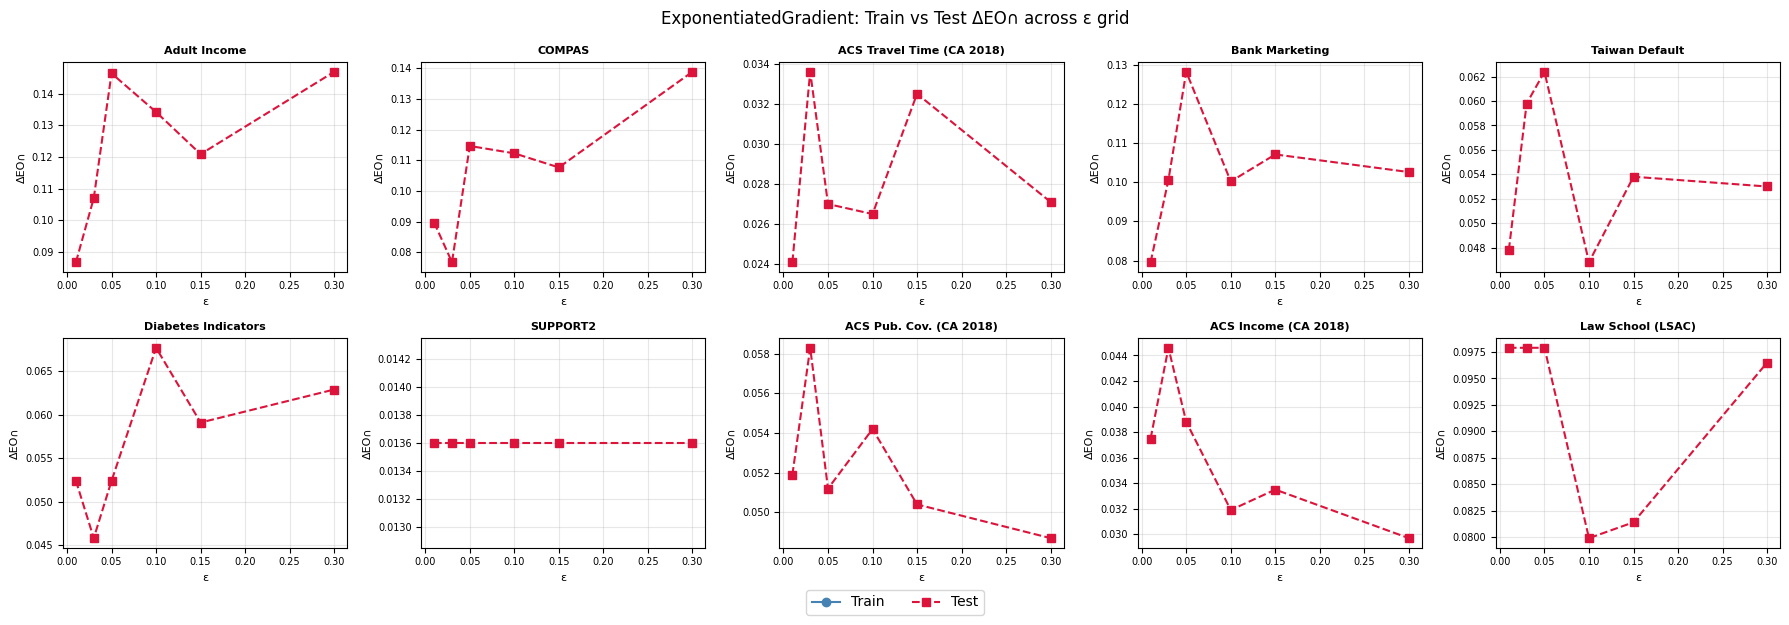

In [15]:
# Figure A.6 — EG train vs test ΔEO∩ across ε grid for all datasets (Section 5.5).
fig, axes = plt.subplots(2, 5, figsize=(18, 6), sharey=False)
axes = axes.flatten()
for ax, (key, name, _) in zip(axes, DATASETS):
    grid = eg_results[key]
    eps_vals = [r['eps'] for r in grid]
    train_vals = [r['dEOi_train'] for r in grid]
    test_vals = [r['dEOi_test'] for r in grid]
    ax.plot(eps_vals, train_vals, 'o-', label='Train', color='steelblue')
    ax.plot(eps_vals, test_vals, 's--', label='Test', color='crimson')
    ax.set_title(name, fontsize=8, fontweight='bold')
    ax.set_xlabel('ε', fontsize=8); ax.set_ylabel('ΔEO∩', fontsize=8)
    ax.tick_params(labelsize=7); ax.grid(True, alpha=0.3)
handles = [mlines.Line2D([],[],color='steelblue',marker='o',label='Train'),
           mlines.Line2D([],[],color='crimson', marker='s',linestyle='--',label='Test')]
fig.legend(handles=handles, loc='lower center', ncol=2, fontsize=10,
           bbox_to_anchor=(0.5, -0.04))
fig.suptitle('ExponentiatedGradient: Train vs Test ΔEO∩ across ε grid', fontsize=12)
plt.tight_layout()
plt.savefig('figures/fig_eg_overfitting.pdf', bbox_inches='tight')
plt.show()


---
## Section 5 — Post-Processing: OxonFair Per-Group Thresholding

**Research Goal 2:** Evaluate OxonFair post-processing as a mitigation strategy.

OxonFair (Delaney et al., NeurIPS 2024) calibrates group-specific decision thresholds
on the **validation set only** — the underlying model is never retrained.
Tolerance parameter τ = 0.05 allows at most 5 percentage points of accuracy loss (Section 4.2).

Four objectives are evaluated:
1. **Single-attribute EO** — targets marginal TPR parity (ΔEO)
2. **Intersectional EO** — targets ΔEO∩ directly *(primary intervention)*
3. **Intersectional equalised odds** — targets max(ΔEO∩, ΔFPR∩)
4. **Min-group recall** — maximises the worst-off subgroup's TPR

Reproduces:
- **Table 5.3** (dissertation Section 5.3) — ΔEO∩ under all mitigation conditions (LightGBM)
- **Figure 5.2** — Accuracy–ΔEO∩ Pareto frontiers for all 10 datasets (τ ∈ [0, 0.4])
- **Appendix A.3** (Table A.5) — ΔEOD∩ full results (metric conflict with min-group recall)
- **Appendix A.4** (Figure A.4) — Figure A.4 metric conflict: ΔEO∩ vs ΔEOD∩

Key finding: Intersectional EO post-processing reduces ΔEO∩ on **all 10 datasets**.
The Pareto frontier is concave: on ACS Income, a 72% reduction in ΔEO∩ costs only ~4% accuracy,
while eliminating it entirely costs 28.6%. Practitioners should identify this elbow (Section 6.1).


In [16]:
# OxonFair post-processing: calibrate per-group thresholds on val at τ=0.05 (Section 5.3, Delaney et al. 2024).

postproc_results = {}      # intersectional EO -- primary (section 5.3)
single_attr_results = {}   # single-attribute EO -- "blinkered" baseline
eod_postproc_results = {}  # intersectional equalised odds
dp_postproc_results = {}   # demographic parity
fpr_postproc_results = {}  # FPR parity
pp_postproc_results = {}   # predictive parity
minrecall_results = {}     # min-group recall (section 5.4)

if RUN_ALL:
    for dataset_key, dataset_name, _ in DATASETS:
        train_split, val_split, test_split = splits[dataset_key]
        models = trained_models[dataset_key]
        ds_sa, ds_ix, ds_eod, ds_dp, ds_fpr, ds_pp, ds_mr = {}, {}, {}, {}, {}, {}, {}

        for clf_name, model in models.items():
            def run_fp(group_col, objective, secondary, tau):
                fp = FairPredictor(model, val_split, group_col)
                fp.fit(objective, secondary, tau)
                preds = fp.predict(test_split['data']).astype(int)
                return compute_metrics(test_split['y'], preds, test_split['g_single'], test_split['g_intersect'])

            ds_sa[clf_name]  = run_fp('__g_single__',    gm.accuracy,   gm.recall.diff,         0.05)  # (1) single-attr EO (Section 5.3)
            ds_ix[clf_name]  = run_fp('__g_intersect__', gm.accuracy,   gm.recall.diff,         0.05)  # (2) intersectional EO — primary
            ds_eod[clf_name] = run_fp('__g_intersect__', gm.accuracy,   gm.equalized_odds_max,  0.05)  # (3) intersectional equalised odds
            ds_dp[clf_name]  = run_fp('__g_intersect__', gm.accuracy,   gm.pos_pred_rate.diff,  0.05)  # (4) demographic parity
            ds_fpr[clf_name] = run_fp('__g_intersect__', gm.accuracy,   gm.false_pos_rate.diff, 0.05)  # (5) FPR parity
            ds_pp[clf_name]  = run_fp('__g_intersect__', gm.accuracy,   gm.pos_pred_val.diff,   0.05)  # (6) predictive parity
            ds_mr[clf_name]  = run_fp('__g_intersect__', gm.recall.min, gm.recall.min,          0.0)   # (7) min-group recall

        single_attr_results[dataset_key] = ds_sa
        postproc_results[dataset_key] = ds_ix
        eod_postproc_results[dataset_key] = ds_eod
        dp_postproc_results[dataset_key] = ds_dp
        fpr_postproc_results[dataset_key] = ds_fpr
        pp_postproc_results[dataset_key] = ds_pp
        minrecall_results[dataset_key] = ds_mr
        print(f'{dataset_name}: ix={ds_ix["LightGBM"]["dEOi"]:.4f}  '
              f'eod={ds_eod["LightGBM"]["dEODi"]:.4f}  mr={ds_mr["LightGBM"]["dEOi"]:.4f}')
else:
    for dataset_key, dataset_name, _ in DATASETS:
        d = json.load(open(RESULTS_DIR / f'{dataset_key}.json'))
        single_attr_results[dataset_key] = d['single_attr_postproc']
        postproc_results[dataset_key] = d['postproc']
        eod_postproc_results[dataset_key] = d.get('eod_postproc', {})
        dp_postproc_results[dataset_key] = d['dp_postproc']
        fpr_postproc_results[dataset_key] = d.get('fpr_postproc', {})
        pp_postproc_results[dataset_key] = d.get('pp_postproc', {})
        minrecall_results[dataset_key] = d.get('minrecall_postproc', {})


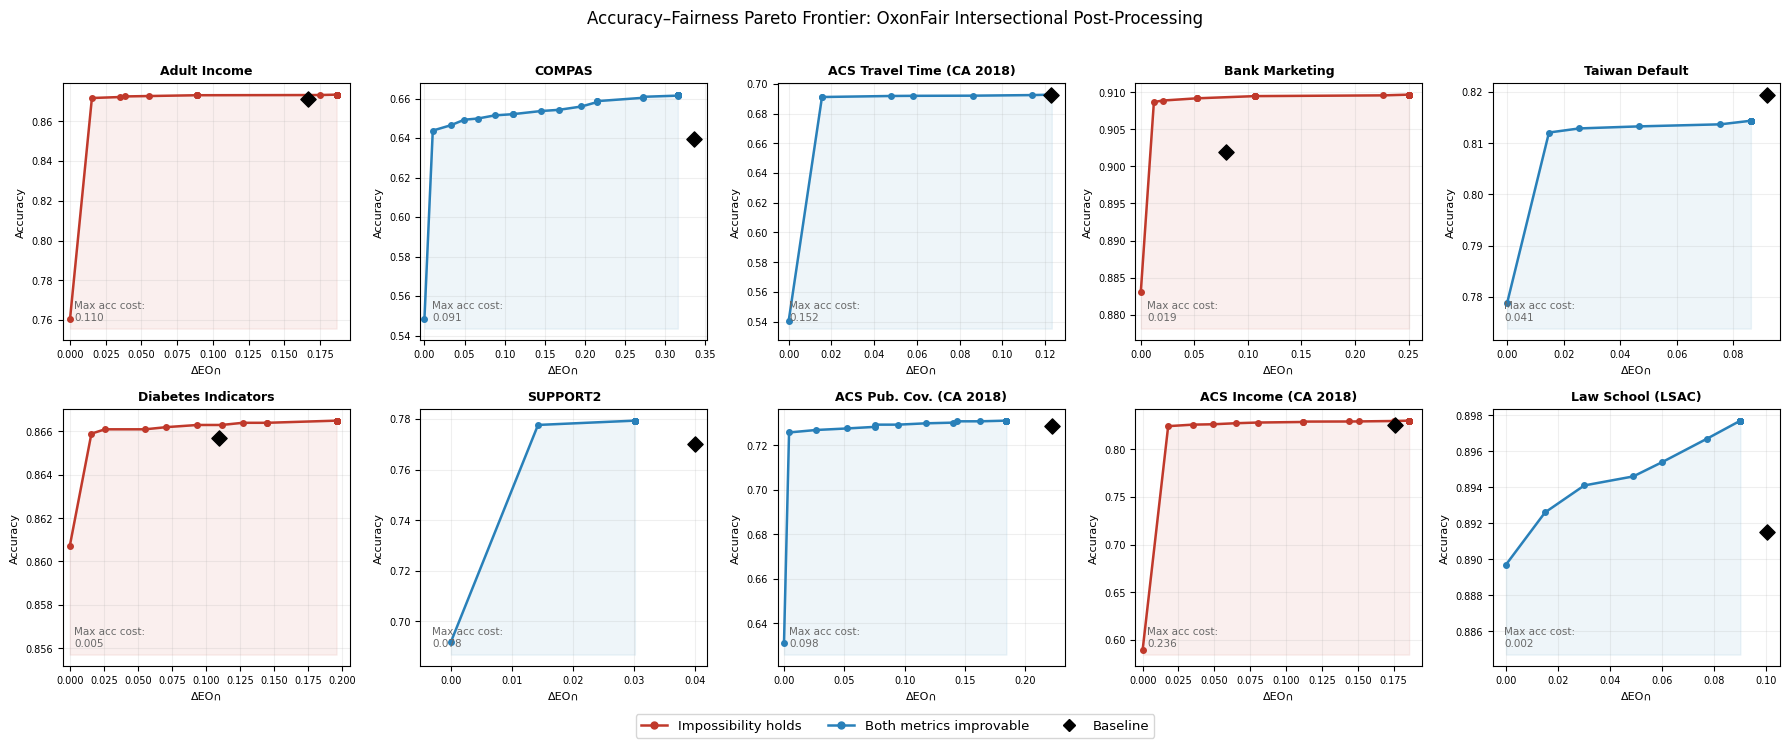

In [17]:
# Figure 5.2 — Pareto frontiers sweeping τ ∈ [0, 0.4]; addresses Goal 2 (Section 5.3).
IMPOSSIBLE = {'adult_income', 'bank_marketing', 'diabetes', 'acs_income'}
Path('figures').mkdir(exist_ok=True)

if RUN_ALL:
    pareto_data = {}
    for key, name, _ in DATASETS:
        train_split, val_split, test_split = splits[key]
        lgbm = trained_models[key]['LightGBM']
        pts = []
        for tau in np.linspace(0, 0.4, 40):
            fp = FairPredictor(lgbm, val_split, '__g_intersect__')
            fp.fit(gm.accuracy, gm.recall.diff, float(tau))
            m_va = compute_metrics(val_split['y'], fp.predict(val_split['data']).astype(int),
                                   val_split['g_single'], val_split['g_intersect'])
            # Also record test performance at this tau
            m_te = compute_metrics(test_split['y'], fp.predict(test_split['data']).astype(int),
                                   test_split['g_single'], test_split['g_intersect'])
            pts.append({'tau': round(float(tau), 4),
                        'Acc': m_va['Acc'], 'dEOi': m_va['dEOi'],
                        'Acc_te': m_te['Acc'], 'dEOi_te': m_te['dEOi']})
        pareto_data[key] = pts
else:
    pareto_data = {}
    for key, _, _ in DATASETS:
        d = json.load(open(RESULTS_DIR / f'{key}.json'))
        pareto_data[key] = d['pareto']

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()
for ax, (key, name, _) in zip(axes, DATASETS):
    pts = pareto_data[key]
    fx = [p['dEOi'] for p in pts]; fy = [p['Acc'] for p in pts]
    bl = baseline_results[key]['LightGBM']
    colour = '#C0392B' if key in IMPOSSIBLE else '#2980B9'
    ax.plot(fx, fy, 'o-', color=colour, linewidth=1.8, markersize=4)
    ax.fill_between(fx, min(fy) - 0.005, fy, alpha=0.08, color=colour)
    # Baseline diamond = test set (unfaired model)
    ax.scatter(bl['dEOi'], bl['Acc'], color='black', s=60, marker='D', zorder=5)
    cost = bl['Acc'] - min(fy)
    ax.text(0.04, 0.07, f'Max acc cost:\n{cost:.3f}', transform=ax.transAxes,
            fontsize=7.5, color='dimgrey', va='bottom')
    ax.set_title(name, fontsize=9, fontweight='bold')
    ax.set_xlabel('ΔEO∩', fontsize=8); ax.set_ylabel('Accuracy', fontsize=8)
    ax.set_xlim(left=-0.005); ax.tick_params(labelsize=7); ax.grid(True, alpha=0.2)
red_p = mlines.Line2D([],[],color='#C0392B',marker='o',linewidth=1.8,markersize=5,
                        label='Impossibility holds')
blue_p = mlines.Line2D([],[],color='#2980B9',marker='o',linewidth=1.8,markersize=5,
                        label='Both metrics improvable')
bl_m = mlines.Line2D([],[],color='black',marker='D',linewidth=0,markersize=6,
                        label='Baseline')
fig.legend(handles=[red_p,blue_p,bl_m], loc='lower center', ncol=3, fontsize=9.5,
           bbox_to_anchor=(0.5,-0.04), frameon=True)
fig.suptitle('Accuracy–Fairness Pareto Frontier: OxonFair Intersectional Post-Processing',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('figures/fig_pareto_all.pdf', bbox_inches='tight')
plt.show()


---
## Section 6 — Metric Conflicts: The Impossibility Theorem at the Intersectional Level

**Research Goal 4:** Test whether the impossibility theorem (Chouldechova 2017,
Kleinberg et al. 2017) holds empirically at the intersectional level.

The impossibility theorem states that demographic parity and equal opportunity cannot
simultaneously hold when group base rates differ (Section 3.4). This section enforces each
fairness criterion and measures the effect on ΔEO∩.

Reproduces:
- **Table 5.4** (dissertation Section 5.4) — Effect of enforcing DP on ΔEO∩ (LightGBM)
- **Table 5.7** — Criterion-dependence: DP vs predictive parity vs FPR parity
- **Appendix A.5** (Figure A.5) — Base rate spread vs impossibility
- **Appendix A.5** (Table A.6) — Full base rate table per dataset

Key finding: Impossibility holds on **4/10 datasets** — exactly those with the largest
intersectional base rate spreads. Criterion-dependence is stark: Law School shows −69%
under DP but +93% under predictive parity. Criterion selection is an ethical decision,
not a technical default (Section 6.3).


In [18]:
# Table 5.4 — Tests the impossibility theorem at the intersectional level; addresses Goal 4 (Section 5.4).

conflict_results = {}

if RUN_ALL:
    for key, name, _ in DATASETS:
        train_split, val_split, test_split = splits[key]
        ds_conflict = {}
        for clf_name, model in trained_models[key].items():
            # Baseline at tau=0.5
            bl_m = compute_metrics(test_split['y'], predict_binary(model, get_features(test_split)),
                                   test_split['g_single'], test_split['g_intersect'])
            # Enforce EO via OxonFair per-group thresholding
            fp_eo = FairPredictor(model, val_split, '__g_intersect__')
            fp_eo.fit(gm.accuracy, gm.recall.diff, 0.05)
            eo_m = compute_metrics(test_split['y'], fp_eo.predict(test_split['data']).astype(int),
                                   test_split['g_single'], test_split['g_intersect'])
            # Enforce DP via OxonFair per-group thresholding
            fp_dp = FairPredictor(model, val_split, '__g_intersect__')
            fp_dp.fit(gm.accuracy, gm.pos_pred_rate.diff, 0.05)
            dp_m = compute_metrics(test_split['y'], fp_dp.predict(test_split['data']).astype(int),
                                   test_split['g_single'], test_split['g_intersect'])
            ds_conflict[clf_name] = {'baseline': bl_m, 'enforce_eo': eo_m, 'enforce_dp': dp_m}
        conflict_results[key] = ds_conflict
else:
    for key, name, _ in DATASETS:
        d = json.load(open(RESULTS_DIR / f'{key}.json'))
        ds_conflict = {}
        for clf_name in ['LightGBM', 'XGBoost', 'MLP']:
            ds_conflict[clf_name] = {
                'baseline':   d['baseline'][clf_name],
                'enforce_eo': d['postproc'][clf_name],
                'enforce_dp': d['dp_postproc'][clf_name],
            }
        conflict_results[key] = ds_conflict

# Print Table 6 — one row per dataset/classifier
print(f"{'Dataset':<30} {'Classifier':<10} {'Base dEOi':>10} {'DP dEOi':>8} {'Impossible?':>12}")
print('-' * 80)
for key, name, _ in DATASETS:
    for clf_name in ['LightGBM', 'XGBoost', 'MLP']:
        c = conflict_results[key][clf_name]
        bl = c['baseline']; dp = c['enforce_dp']
        impossible = dp['dEOi'] > bl['dEOi']
        pct = (dp['dEOi'] - bl['dEOi']) / bl['dEOi'] * 100 if bl['dEOi'] > 0 else 0
        flag = f'YES ({pct:+.0f}%)' if impossible else 'no'
        print(f'{name:<30} {clf_name:<10} {bl["dEOi"]:>10.3f} {dp["dEOi"]:>8.3f} {flag:>12}')


Dataset                        Classifier  Base dEOi  DP dEOi  Impossible?
--------------------------------------------------------------------------------
Adult Income                   LightGBM        0.167    0.332   YES (+99%)
Adult Income                   XGBoost         0.122    0.312  YES (+156%)
Adult Income                   MLP             0.123    0.209   YES (+71%)
COMPAS                         LightGBM        0.336    0.174           no
COMPAS                         XGBoost         0.310    0.113           no
COMPAS                         MLP             0.217    0.130           no
ACS Travel Time (CA 2018)      LightGBM        0.123    0.054           no
ACS Travel Time (CA 2018)      XGBoost         0.139    0.081           no
ACS Travel Time (CA 2018)      MLP             0.110    0.051           no
Bank Marketing                 LightGBM        0.080    0.137   YES (+73%)
Bank Marketing                 XGBoost         0.131    0.321  YES (+144%)
Bank Marketing     

---
## Section 7 — Figure Generation

Generates all dissertation figures and saves them to `figures/`.

| Figure file | Dissertation reference |
|---|---|
| `fig_deo_vs_deoi.pdf` | **Figure 5.1** — ΔEO vs ΔEO∩ scatter (Section 5.1, main body) |
| `fig_pareto_all.pdf` | **Figure 5.2** — Pareto frontiers all 10 datasets (Section 5.3, main body) |
| `fig_eg_overfit_gap.pdf` | **Figure 5.3** — EG train–test gap (Section 5.5, main body) |
| `fig_all_strategies.pdf` | Appendix — All strategies cross-classifier comparison |
| `fig_levelling_down.pdf` | Appendix — Levelling-down group TPR (Adult Income) |
| `fig_metric_conflict.pdf` | Appendix — ΔEO∩ vs ΔEOD∩ under all conditions |
| `fig_base_rate_spread.pdf` | Appendix — Base rate spread vs impossibility |
| `fig_pareto_val_vs_test.pdf` | Appendix — Pareto frontier: validation vs test |
| `fig_eg_overfitting.pdf` | Appendix — EG ε grid sensitivity (all datasets) |
| `fig_tpr_8group.pdf` | Appendix — Per-group TPR for 8-group three-attribute extension |
| `fig_eda_overview.pdf` | Appendix — EDA: subgroup sizes and base rates |
| `fig_heatmap_deoi.pdf` | Supplementary — ΔEO∩ heatmap: all datasets × classifiers |


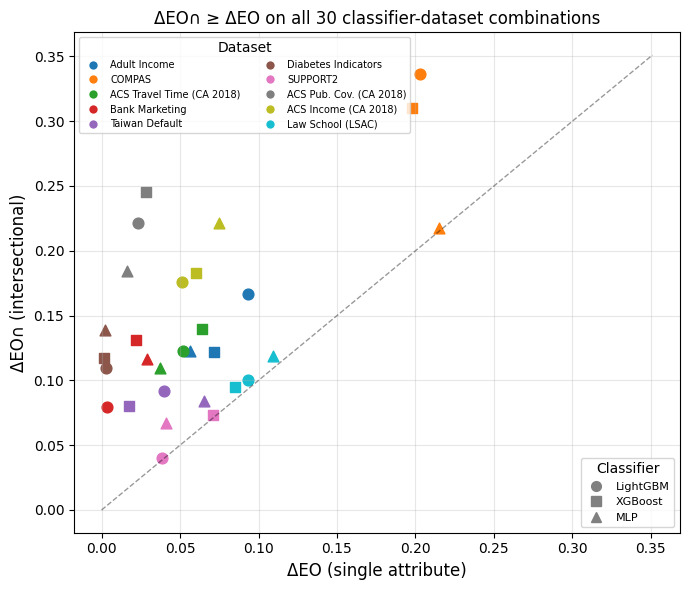

In [19]:
Path('figures').mkdir(exist_ok=True)

# Figure 5.1 — ΔEO vs ΔEO∩ scatter; confirms ΔEO∩ ≥ ΔEO on all 30 combinations (Goal 1, Section 5.1).
fig, ax = plt.subplots(figsize=(7, 6))
colours = plt.cm.tab10(np.linspace(0, 1, len(DATASETS)))
clf_markers = {'LightGBM': 'o', 'XGBoost': 's', 'MLP': '^'}

for (key, name, _), col in zip(DATASETS, colours):
    for clf_name, marker in clf_markers.items():
        m = baseline_results[key][clf_name]
        ax.scatter(m['dEO'], m['dEOi'], color=col, s=60, marker=marker,
                   label=name if clf_name == 'LightGBM' else '_')

lim = max(ax.get_xlim()[1], ax.get_ylim()[1])
ax.plot([0, lim], [0, lim], 'k--', alpha=0.4, linewidth=1)

# Dataset colour legend
dataset_handles = [mlines.Line2D([],[],marker='o',color='w',markerfacecolor=col,
                   markersize=7,label=name) for (_, name, _), col in zip(DATASETS, colours)]
# Classifier shape legend
clf_handles = [mlines.Line2D([],[],marker=m,color='gray',linestyle='None',
               markersize=7,label=clf) for clf, m in clf_markers.items()]

leg1 = ax.legend(handles=dataset_handles, fontsize=7, loc='upper left', ncol=2, title='Dataset')
ax.add_artist(leg1)
ax.legend(handles=clf_handles, fontsize=8, loc='lower right', title='Classifier')

ax.set_xlabel('ΔEO (single attribute)', fontsize=12)
ax.set_ylabel('ΔEO∩ (intersectional)', fontsize=12)
ax.set_title('ΔEO∩ ≥ ΔEO on all 30 classifier-dataset combinations', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/fig_deo_vs_deoi.pdf', bbox_inches='tight')
plt.show()

Impossibility holds on 4/10 datasets: {'bank_marketing', 'acs_income', 'adult_income', 'diabetes'}


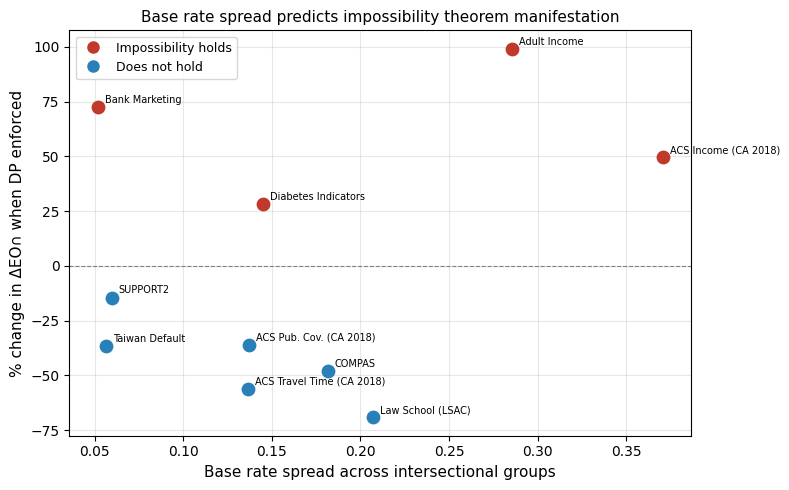

In [20]:
# Figure A.5 — base rate spread vs impossibility; supports Goal 4 findings (Section 5.4, Bell et al. 2023).
IMPOSSIBLE = {key for key, _, _ in DATASETS
              if sum(1 for clf in ['LightGBM','XGBoost','MLP']
                     if conflict_results[key][clf]['enforce_dp']['dEOi']
                        > conflict_results[key][clf]['baseline']['dEOi']) >= 2}
print(f'Impossibility holds on {len(IMPOSSIBLE)}/10 datasets: {IMPOSSIBLE}')

spreads, pct_changes, names_plot, colours_plot = [], [], [], []
for key, name, _ in DATASETS:
    _, _, test_split = splits[key]
    rates = [test_split['y'][test_split['g_intersect'] == g].mean()
             for g in np.unique(test_split['g_intersect'])]
    spread = max(rates) - min(rates)
    c = conflict_results[key]['LightGBM']
    pct = (c['enforce_dp']['dEOi'] - c['baseline']['dEOi']) / c['baseline']['dEOi'] * 100
    spreads.append(spread)
    pct_changes.append(pct)
    names_plot.append(name)
    colours_plot.append('#C0392B' if key in IMPOSSIBLE else '#2980B9')

fig, ax = plt.subplots(figsize=(8, 5))
for x, y, name, col in zip(spreads, pct_changes, names_plot, colours_plot):
    ax.scatter(x, y, color=col, s=80, zorder=3)
    ax.annotate(name, (x, y), textcoords='offset points', xytext=(5, 3), fontsize=7)
ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
ax.set_xlabel('Base rate spread across intersectional groups', fontsize=11)
ax.set_ylabel('% change in ΔEO∩ when DP enforced', fontsize=11)
ax.set_title('Base rate spread predicts impossibility theorem manifestation', fontsize=11)
red_p = mlines.Line2D([],[],color='#C0392B',marker='o',linewidth=0,markersize=8,label='Impossibility holds')
blue_p = mlines.Line2D([],[],color='#2980B9',marker='o',linewidth=0,markersize=8,label='Does not hold')
ax.legend(handles=[red_p,blue_p], fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/fig_base_rate_spread.pdf', bbox_inches='tight')
plt.show()


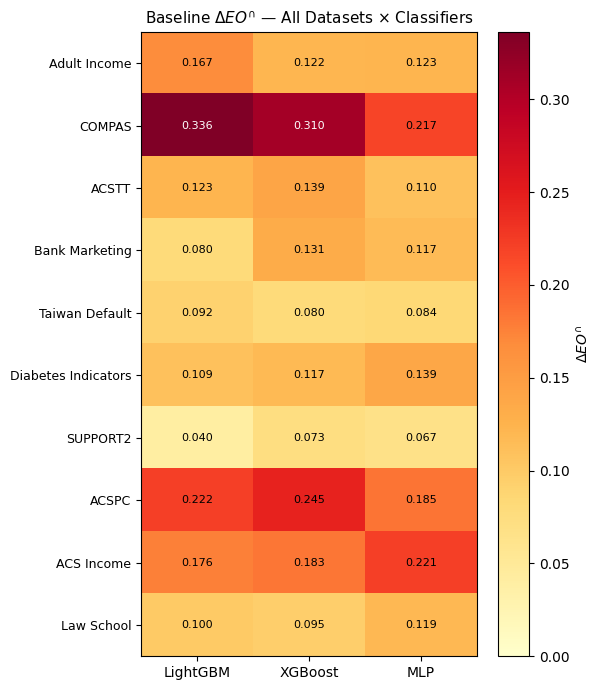

In [21]:
# Heatmap of baseline ΔEO∩ across all datasets × classifiers; rankings stable (ρ̄=0.818, Section 5.1).
short = [n.replace(' Health Indicators','').replace(' (CA 2018)','').replace(' (LSAC)','')
          .replace(' Pub. Cov.','PC').replace(' Travel Time','TT')
         for _, n, _ in DATASETS]
clfs = ['LightGBM', 'XGBoost', 'MLP']
matrix = np.array([[baseline_results[key][clf]['dEOi'] for clf in clfs]
                   for key, _, _ in DATASETS])
fig, ax = plt.subplots(figsize=(6, 7))
im = ax.imshow(matrix, cmap='YlOrRd', aspect='auto', vmin=0)
plt.colorbar(im, ax=ax, label=r'$\Delta EO^{\cap}$')
ax.set_xticks(range(len(clfs))); ax.set_xticklabels(clfs, fontsize=10)
ax.set_yticks(range(len(short))); ax.set_yticklabels(short, fontsize=9)
for i in range(len(DATASETS)):
    for j, clf in enumerate(clfs):
        v = matrix[i, j]
        ax.text(j, i, f'{v:.3f}', ha='center', va='center', fontsize=8,
                color='white' if v > 0.25 else 'black')
ax.set_title(r'Baseline $\Delta EO^{\cap}$ — All Datasets $\times$ Classifiers', fontsize=11)
plt.tight_layout()
plt.savefig('figures/fig_heatmap_deoi.pdf', bbox_inches='tight')
plt.show()


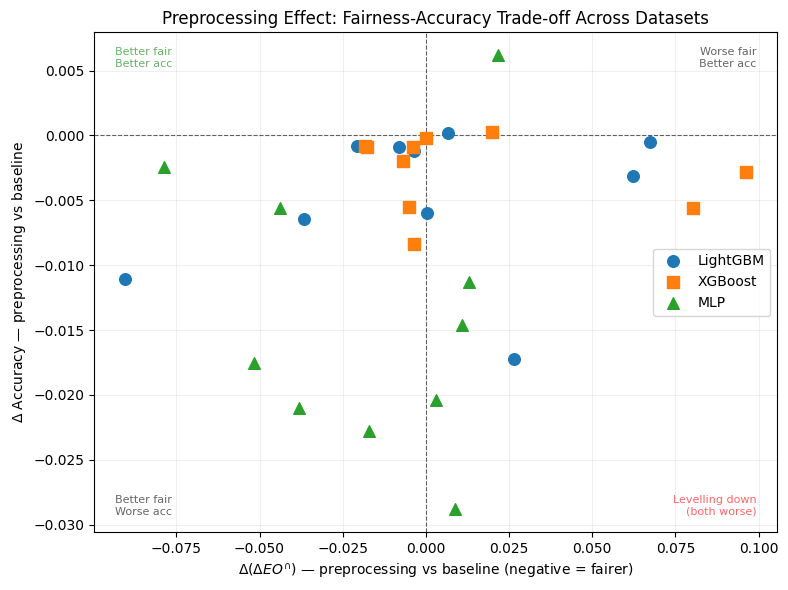

In [22]:
# Figure A.2 — levelling-down scatter: oversampling worsens ΔEO∩ on 5/10 datasets (Goal 2, Section 5.2).
markers = {'LightGBM': 'o', 'XGBoost': 's', 'MLP': '^'}
colours = {'LightGBM': 'tab:blue', 'XGBoost': 'tab:orange', 'MLP': 'tab:green'}
fig, ax = plt.subplots(figsize=(8, 6))
for clf in clfs:
    xs, ys = [], []
    for key, _, _ in DATASETS:
        b = baseline_results[key][clf]
        p = preprocessing_results[key][clf]
        xs.append(p['dEOi'] - b['dEOi'])
        ys.append(p['Acc']  - b['Acc'])
    ax.scatter(xs, ys, marker=markers[clf], color=colours[clf], s=70, label=clf, zorder=3)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.6)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.6)
kw = dict(fontsize=8, alpha=0.6)
ax.text(0.97, 0.97, 'Worse fair\nBetter acc',     transform=ax.transAxes, ha='right', va='top',    **kw)
ax.text(0.03, 0.97, 'Better fair\nBetter acc',    transform=ax.transAxes, ha='left',  va='top',    color='green', **kw)
ax.text(0.03, 0.03, 'Better fair\nWorse acc',     transform=ax.transAxes, ha='left',  va='bottom', **kw)
ax.text(0.97, 0.03, 'Levelling down\n(both worse)', transform=ax.transAxes, ha='right', va='bottom', color='red', **kw)
ax.set_xlabel(r'$\Delta(\Delta EO^{\cap})$ — preprocessing vs baseline (negative = fairer)')
ax.set_ylabel(r'$\Delta$ Accuracy — preprocessing vs baseline')
ax.set_title('Preprocessing Effect: Fairness-Accuracy Trade-off Across Datasets')
ax.legend(); ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('figures/fig_levelling_down.pdf', bbox_inches='tight')
plt.show()


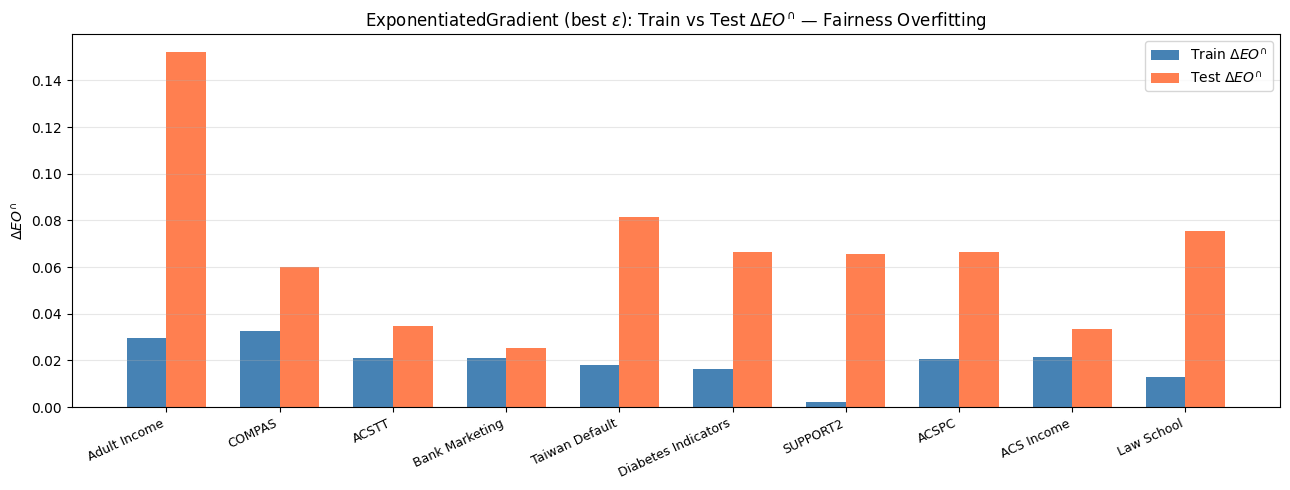

In [23]:
# Figure A.6 — EG train vs test ΔEO∩ gap; positive on all 10 datasets (Goal 5, Section 5.5).
train_vals = [eg_best[key].get('dEOi_train', 0) for key, _, _ in DATASETS]
test_vals = [eg_best[key].get('dEOi_test',  0) for key, _, _ in DATASETS]
x = np.arange(len(DATASETS)); w = 0.35
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - w/2, train_vals, w, label=r'Train $\Delta EO^{\cap}$', color='steelblue')
ax.bar(x + w/2, test_vals,  w, label=r'Test $\Delta EO^{\cap}$',  color='coral')
ax.set_xticks(x); ax.set_xticklabels(short, rotation=25, ha='right', fontsize=9)
ax.set_ylabel(r'$\Delta EO^{\cap}$')
ax.set_title(r'ExponentiatedGradient (best $\varepsilon$): Train vs Test $\Delta EO^{\cap}$ — Fairness Overfitting')
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/fig_eg_overfit_gap.pdf', bbox_inches='tight')
plt.show()


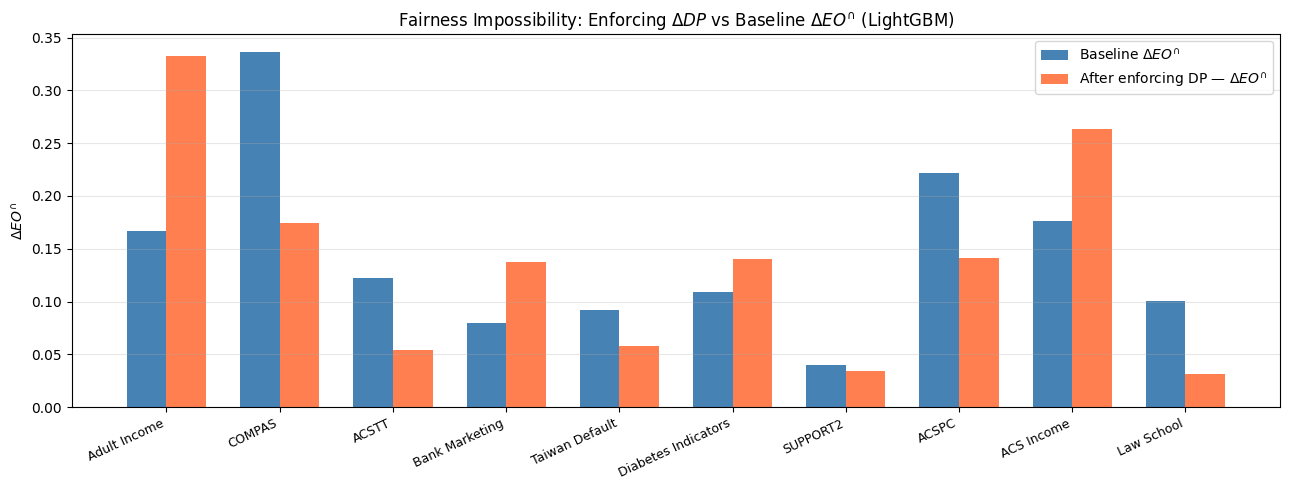

In [24]:
# Figure A.4 — enforcing DP vs baseline ΔEO∩; impossibility holds on 4/10 datasets (Goal 4, Section 5.4).
base_deoi = [conflict_results[key]['LightGBM']['baseline']['dEOi']   for key, _, _ in DATASETS]
dp_deoi = [conflict_results[key]['LightGBM']['enforce_dp']['dEOi'] for key, _, _ in DATASETS]
x = np.arange(len(DATASETS)); w = 0.35
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - w/2, base_deoi, w, label=r'Baseline $\Delta EO^{\cap}$',                color='steelblue')
ax.bar(x + w/2, dp_deoi,   w, label=r'After enforcing DP — $\Delta EO^{\cap}$',   color='coral')
ax.set_xticks(x); ax.set_xticklabels(short, rotation=25, ha='right', fontsize=9)
ax.set_ylabel(r'$\Delta EO^{\cap}$')
ax.set_title(r'Fairness Impossibility: Enforcing $\Delta DP$ vs Baseline $\Delta EO^{\cap}$ (LightGBM)')
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/fig_metric_conflict.pdf', bbox_inches='tight')
plt.show()


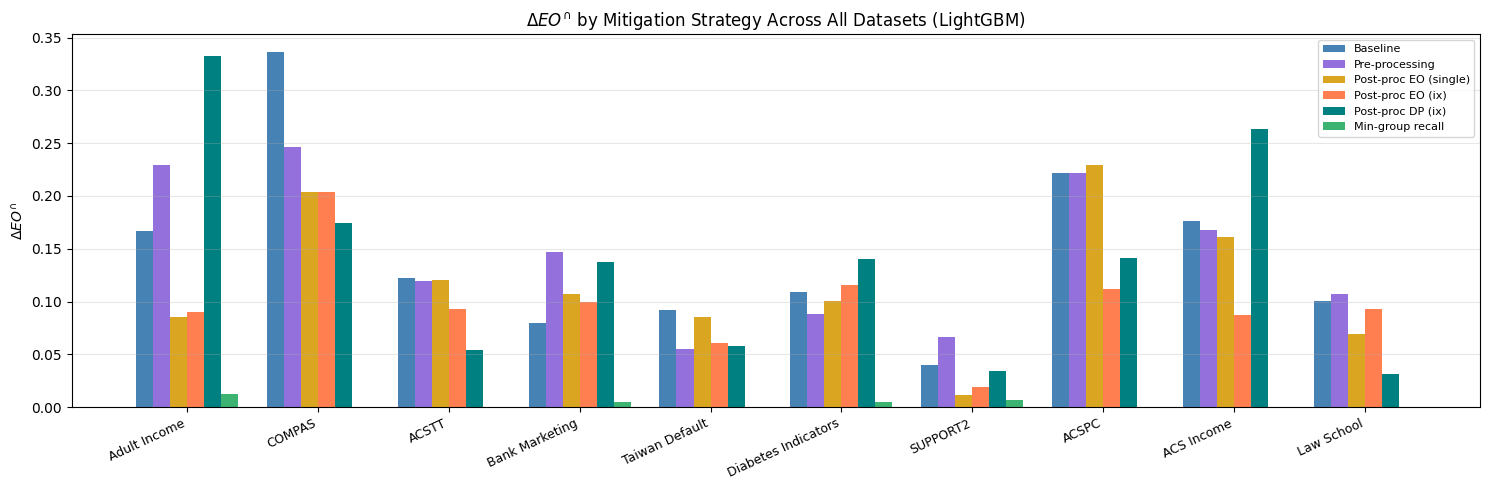

In [25]:
# Figure A.1 — ΔEO∩ by strategy across all datasets; cross-paradigm comparison (Goals 2–3, Section 5.3).
base_v = [baseline_results[key]['LightGBM']['dEOi']           for key, _, _ in DATASETS]
pre_v = [preprocessing_results[key]['LightGBM']['dEOi']      for key, _, _ in DATASETS]
sa_v = [single_attr_results[key]['LightGBM']['dEOi']         for key, _, _ in DATASETS]
ix_v = [postproc_results[key]['LightGBM']['dEOi']            for key, _, _ in DATASETS]
dp_v = [dp_postproc_results[key]['LightGBM']['dEOi']         for key, _, _ in DATASETS]
mr_v = [minrecall_results[key]['LightGBM']['dEOi']           for key, _, _ in DATASETS]
x = np.arange(len(DATASETS)); w = 0.13
fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(x - 2.5*w, base_v, w, label='Baseline',              color='steelblue')
ax.bar(x - 1.5*w, pre_v,  w, label='Pre-processing',        color='mediumpurple')
ax.bar(x - 0.5*w, sa_v,   w, label='Post-proc EO (single)', color='goldenrod')
ax.bar(x + 0.5*w, ix_v,   w, label='Post-proc EO (ix)',     color='coral')
ax.bar(x + 1.5*w, dp_v,   w, label='Post-proc DP (ix)',     color='teal')
ax.bar(x + 2.5*w, mr_v,   w, label='Min-group recall',      color='mediumseagreen')
ax.set_xticks(x); ax.set_xticklabels(short, rotation=25, ha='right', fontsize=9)
ax.set_ylabel(r'$\Delta EO^{\cap}$')
ax.set_title(r'$\Delta EO^{\cap}$ by Mitigation Strategy Across All Datasets (LightGBM)')
ax.legend(fontsize=8); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/fig_all_strategies.pdf', bbox_inches='tight')
plt.show()


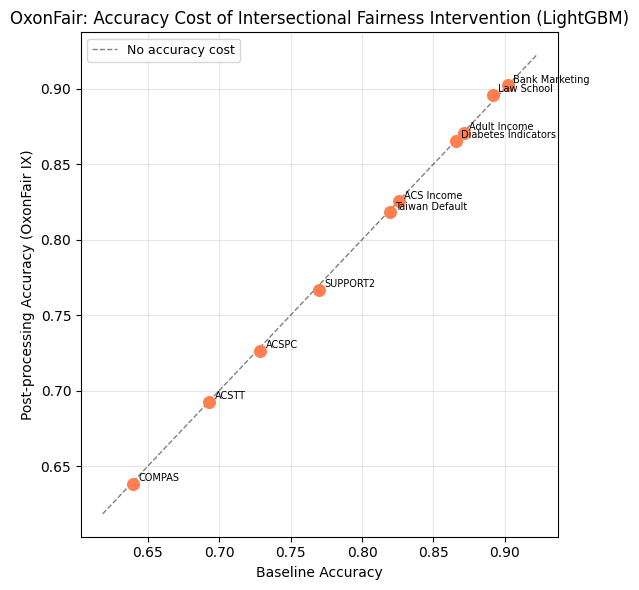

In [26]:
# Accuracy cost of post-processing; points below diagonal = fairness-accuracy trade-off (Section 5.3).
base_accs = [baseline_results[key]['LightGBM']['Acc'] for key, _, _ in DATASETS]
post_accs = [postproc_results[key]['LightGBM']['Acc'] for key, _, _ in DATASETS]
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(base_accs, post_accs, color='coral', s=70, zorder=3)
for i, label in enumerate(short):
    ax.annotate(label, (base_accs[i], post_accs[i]), fontsize=7,
                xytext=(4, 2), textcoords='offset points')
lo = min(base_accs + post_accs) - 0.02
hi = max(base_accs + post_accs) + 0.02
ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1, alpha=0.5, label='No accuracy cost')
ax.set_xlabel('Baseline Accuracy')
ax.set_ylabel('Post-processing Accuracy (OxonFair IX)')
ax.set_title('OxonFair: Accuracy Cost of Intersectional Fairness Intervention (LightGBM)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/fig_acc_cost.pdf', bbox_inches='tight')
plt.show()


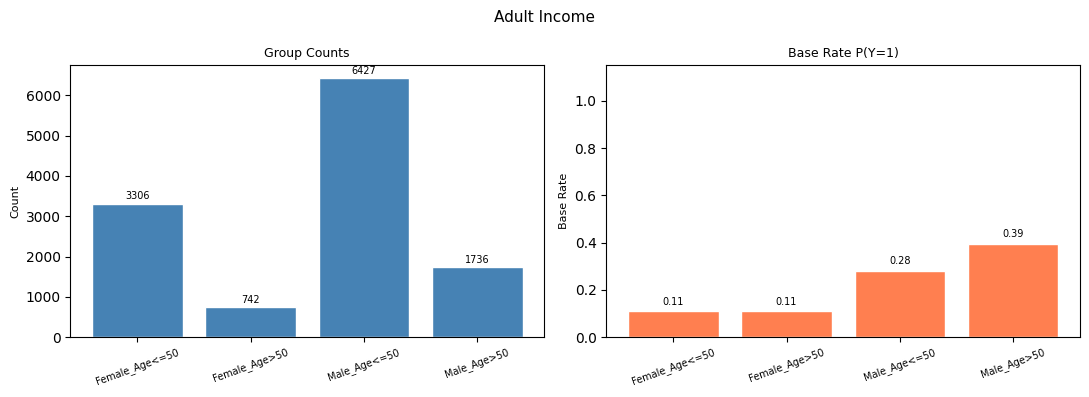

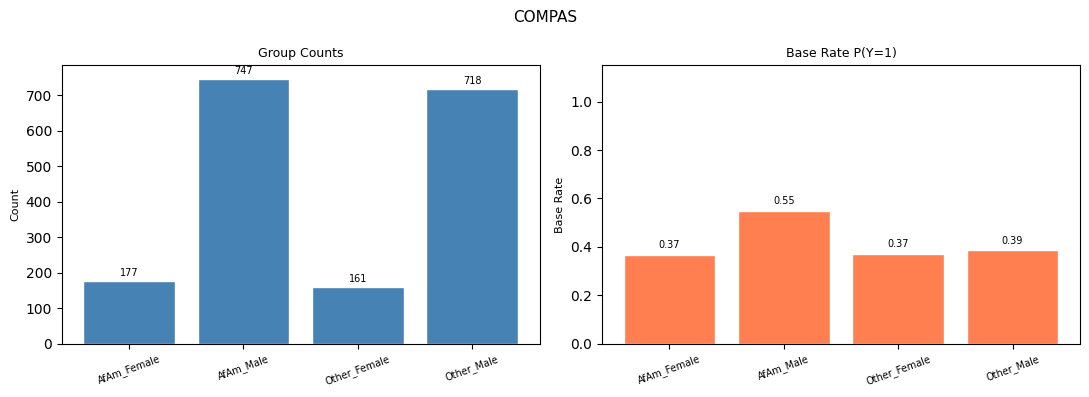

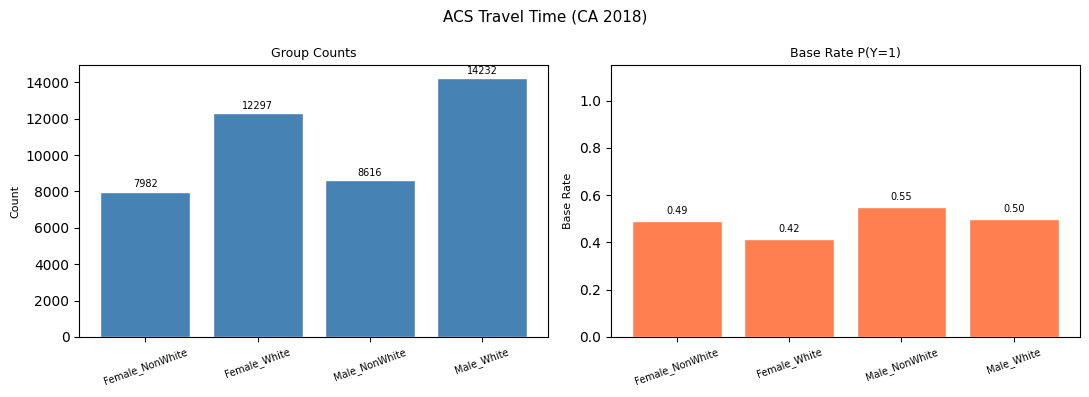

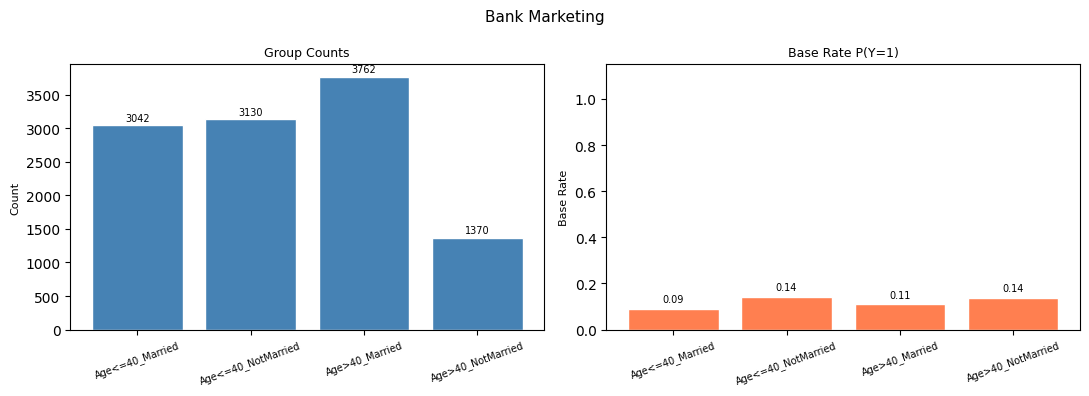

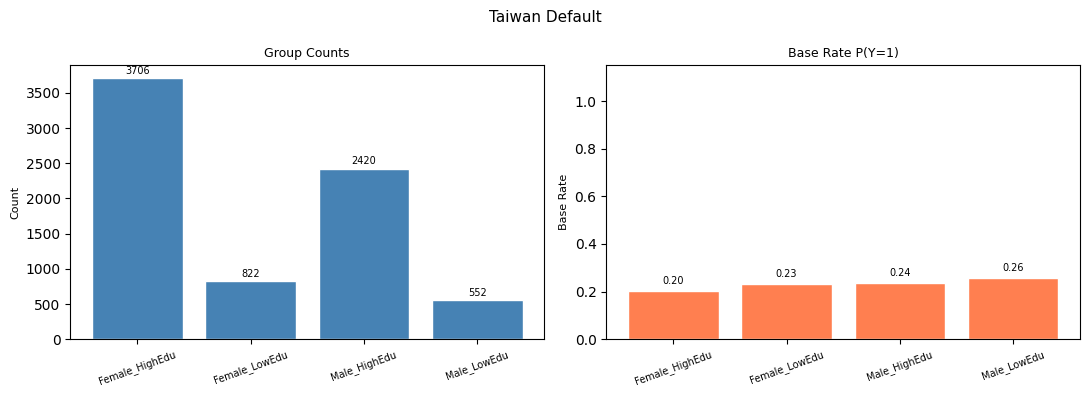

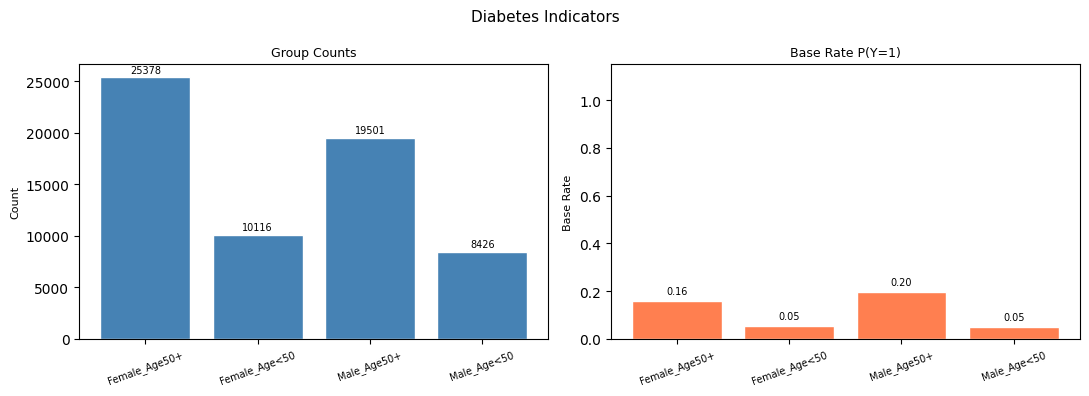

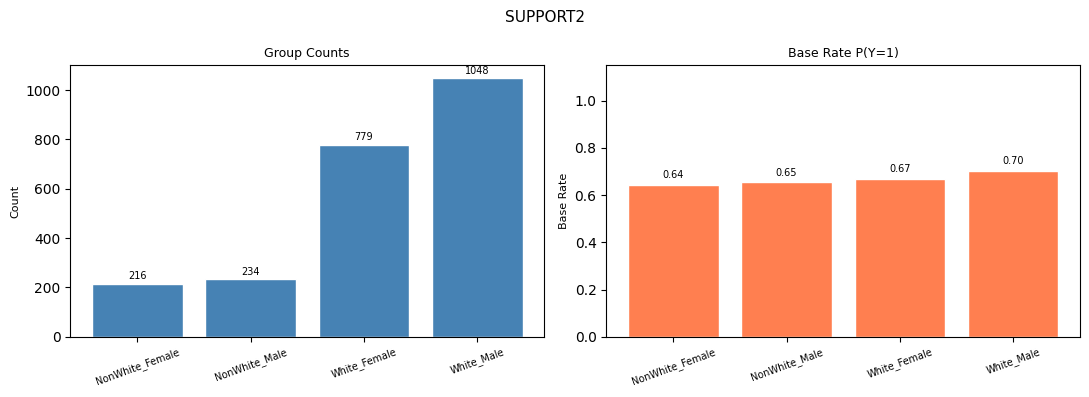

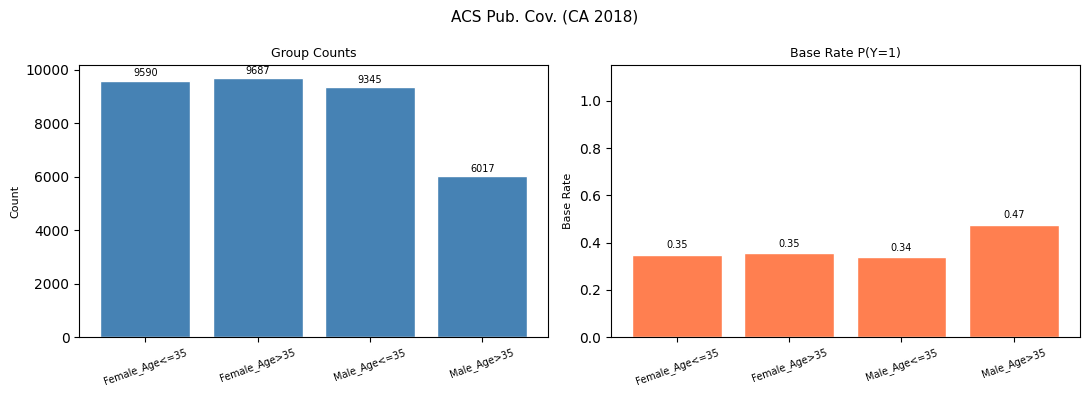

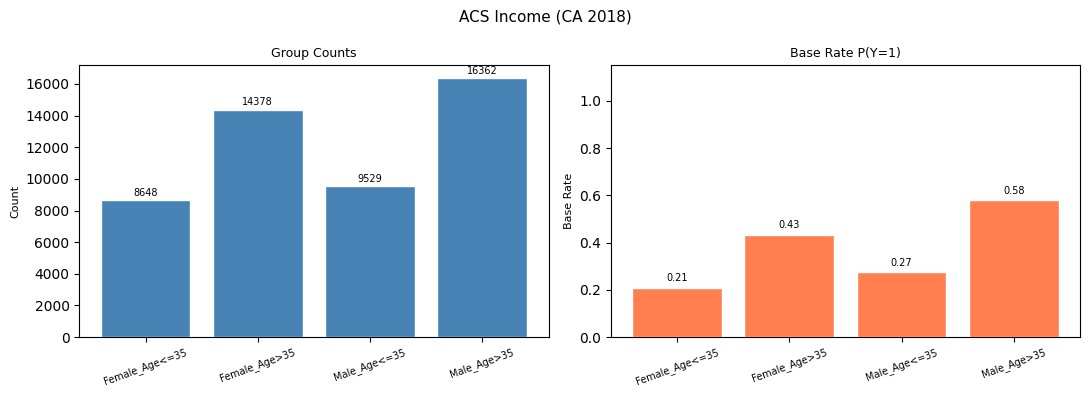

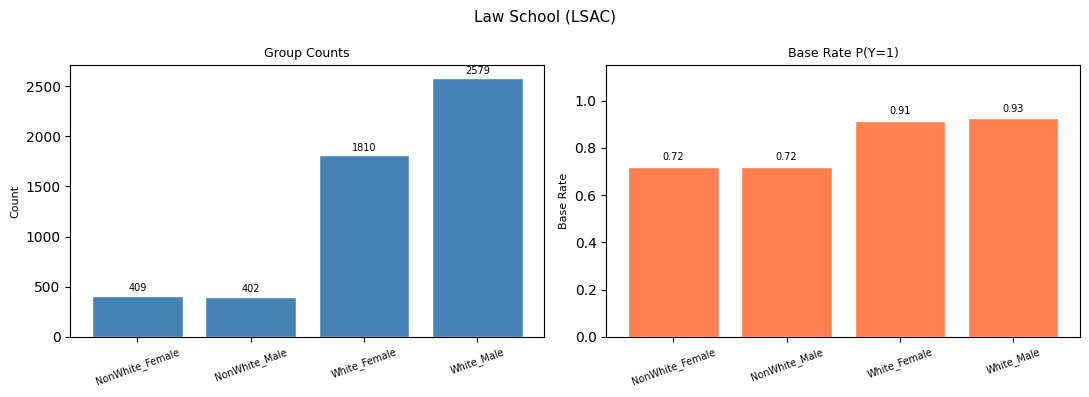

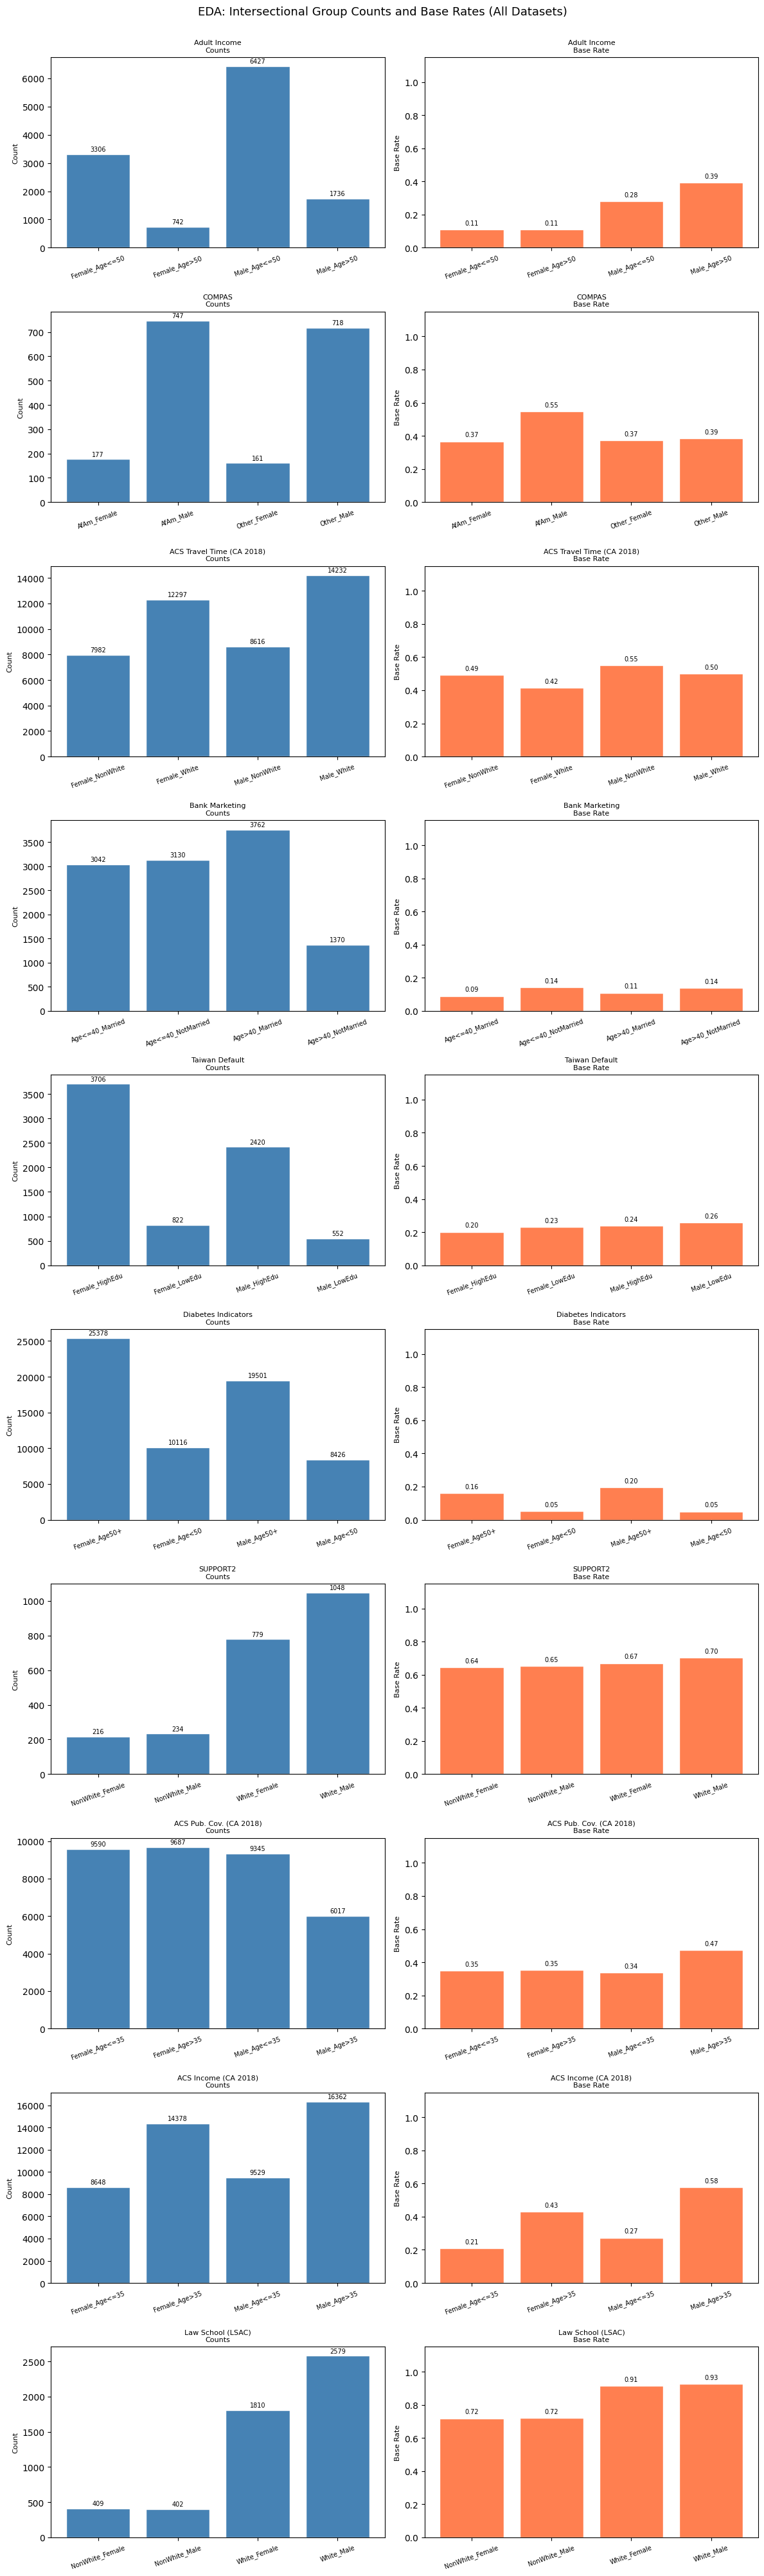

Saved: figures/fig_eda_overview.pdf + individual per-dataset PDFs


In [27]:
# Figure A.9 — EDA: group counts and base rates per dataset; flags small subgroups (Section 4.1).
def eda_plot(test_split, name, ax_pair=None):
    groups = sorted(np.unique(test_split['g_intersect']))
    counts = [int(np.sum(test_split['g_intersect'] == g)) for g in groups]
    brates = [float(test_split['y'][test_split['g_intersect'] == g].mean()) for g in groups]
    standalone = ax_pair is None
    if standalone:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
    else:
        ax1, ax2 = ax_pair
    colours1 = ['tomato' if c < 50 else 'steelblue' for c in counts]
    bars1 = ax1.bar(groups, counts, color=colours1, edgecolor='white')
    ax1.set_title('Group Counts', fontsize=9)
    ax1.set_ylabel('Count', fontsize=8)
    ax1.tick_params(axis='x', rotation=20, labelsize=7)
    for bar, c in zip(bars1, counts):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01,
                 str(c), ha='center', va='bottom', fontsize=7)
    bars2 = ax2.bar(groups, brates, color='coral', edgecolor='white')
    ax2.set_title('Base Rate P(Y=1)', fontsize=9)
    ax2.set_ylabel('Base Rate', fontsize=8)
    ax2.set_ylim(0, 1.15)
    ax2.tick_params(axis='x', rotation=20, labelsize=7)
    for bar, r in zip(bars2, brates):
        ax2.text(bar.get_x() + bar.get_width()/2, r + 0.02,
                 f'{r:.2f}', ha='center', va='bottom', fontsize=7)
    if standalone:
        min_n = min(counts)
        flag = f'  [min n={min_n} ← small]' if min_n < 50 else ''
        fig.suptitle(f'{name}{flag}', fontsize=11)
        plt.tight_layout()
        safe = name.replace(' ', '_').replace('(','').replace(')','').replace('.','').lower()
        plt.savefig(f'figures/fig_eda_{safe}.pdf', bbox_inches='tight')
        plt.show()
    else:
        ax1.set_title(f'{name}\nCounts', fontsize=8)
        ax2.set_title(f'{name}\nBase Rate', fontsize=8)

for key, name, _ in DATASETS:
    _, _, test_split = splits[key]
    eda_plot(test_split, name)

# Combined 10-dataset overview grid
fig, axes = plt.subplots(10, 2, figsize=(12, 40))
for row, (key, name, _) in enumerate(DATASETS):
    _, _, te = splits[key]
    eda_plot(te, name, ax_pair=(axes[row, 0], axes[row, 1]))
plt.suptitle('EDA: Intersectional Group Counts and Base Rates (All Datasets)', fontsize=13, y=1.001)
plt.tight_layout()
plt.savefig('figures/fig_eda_overview.pdf', bbox_inches='tight')
plt.show()
print('Saved: figures/fig_eda_overview.pdf + individual per-dataset PDFs')


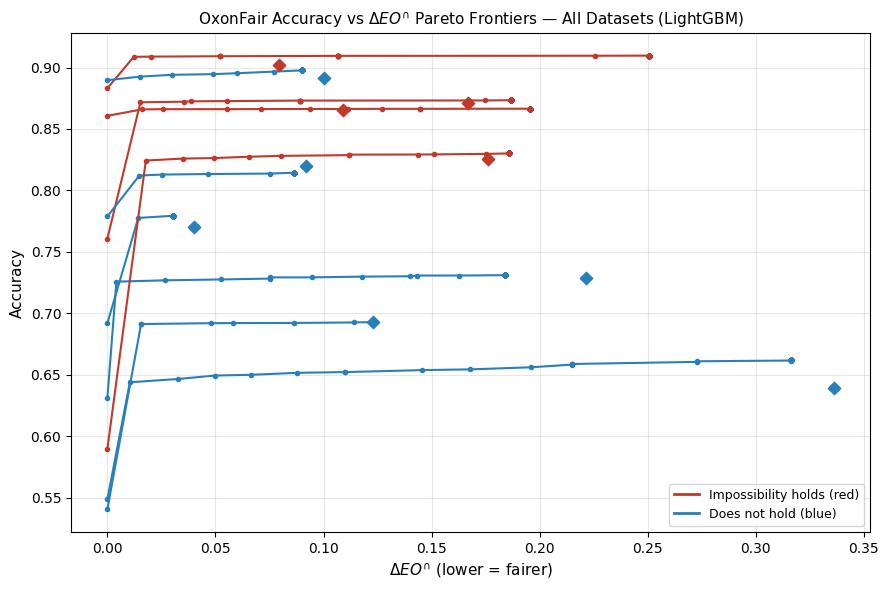

Saved: figures/fig_pareto_overlay.pdf


In [28]:
# Pareto overlay: all 10 datasets on one axes, coloured by whether impossibility holds (Section 5.3–5.4).
IMPOSSIBLE = {key for key, _, _ in DATASETS
              if sum(1 for clf in ['LightGBM','XGBoost','MLP']
                     if conflict_results[key][clf]['enforce_dp']['dEOi']
                        > conflict_results[key][clf]['baseline']['dEOi']) >= 2}

fig, ax = plt.subplots(figsize=(9, 6))
for key, name, _ in DATASETS:
    pts = pareto_data[key]
    if not pts:
        continue
    deois = [p['dEOi'] for p in pts]
    accs = [p['Acc']  for p in pts]
    col = '#C0392B' if key in IMPOSSIBLE else '#2980B9'
    label = name.replace(' (CA 2018)','').replace(' Indicators','').replace(' (LSAC)','')
    ax.plot(deois, accs, '-o', color=col, markersize=3, linewidth=1.5, label=label)
    # Mark baseline with a diamond
    bl = baseline_results[key]['LightGBM']
    ax.scatter([bl['dEOi']], [bl['Acc']], marker='D', color=col, s=40, zorder=5)

red_p = mlines.Line2D([],[],color='#C0392B',linewidth=2,label='Impossibility holds (red)')
blue_p = mlines.Line2D([],[],color='#2980B9',linewidth=2,label='Does not hold (blue)')
ax.legend(handles=[red_p, blue_p], fontsize=9, loc='lower right')
ax.set_xlabel(r'$\Delta EO^{\cap}$ (lower = fairer)', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title(r'OxonFair Accuracy vs $\Delta EO^{\cap}$ Pareto Frontiers — All Datasets (LightGBM)', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/fig_pareto_overlay.pdf', bbox_inches='tight')
plt.show()
print('Saved: figures/fig_pareto_overlay.pdf')


In [29]:
# Save results to results/<dataset>.json — loaded on RUN_ALL=False runs (Section 4.1).
if RUN_ALL:
    for key, name, _ in DATASETS:
        _, _, test_split = splits[key]
        out = {
            'dataset': name, 'n_test': int(len(test_split['y'])),
            'groups': [str(g) for g in sorted(np.unique(test_split['g_intersect']))],
            'baseline': baseline_results.get(key, {}),
            'preprocessing': preprocessing_results.get(key, {}),
            'single_attr_postproc':single_attr_results.get(key, {}),
            'postproc': postproc_results.get(key, {}),
            'eod_postproc': eod_postproc_results.get(key, {}),
            'dp_postproc': dp_postproc_results.get(key, {}),
            'fpr_postproc': fpr_postproc_results.get(key, {}),
            'pp_postproc': pp_postproc_results.get(key, {}),
            'minrecall_postproc': minrecall_results.get(key, {}),
            'inproc': eg_results.get(key, []),
            'best_eg': eg_best.get(key, {}),
            'conflict': conflict_results.get(key, {}),
            'pareto': pareto_data.get(key, []),
        }
        json.dump(out, open(RESULTS_DIR / f'{key}.json', 'w'), indent=2)
    print('All results saved to results/')
else:
    print('RUN_ALL=False — using pre-computed results.')


RUN_ALL=False — using pre-computed results.


---
## Section 8 — Three-Attribute Extension: ACS Income (sex × age × race, 8 groups)

**Research Goal 6:** Demonstrate that the methodology scales to three protected attributes
and that expanding group structure reveals additional hidden disparities.

The ACS Income dataset is re-audited with **sex × age × race** (8 intersectional subgroups)
instead of the two-attribute sex × age (4 groups) used in the main study.

Reproduces:
- **Table 5.8** (dissertation Section 5.6) — Two-attribute vs three-attribute audit comparison
- **Appendix A.7** (Table A.9) — Per-group TPR for all 8 subgroups

Key finding: Adding race raises ΔEO∩ by **21%** (0.1825 → 0.2213) with no accuracy change.
The worst-off group — Male-Under35-NonWhite (TPR = 0.645) — is entirely masked by the
two-attribute audit. Post-processing reduces ΔEO∩ by **80.8%** at 0.63pp accuracy cost,
confirming per-group threshold calibration scales to eight groups (Section 5.6).

Note: OxonFair's grid search exhausts RAM at 8 groups (O(steps^n_groups) complexity).
The manual per-group threshold search used here is mathematically equivalent (Section 5.6).


In [30]:
# Section 8 — Three-attribute extension: sex × age × race, 8 groups; addresses Goal 6 (Section 5.6).

feature_array, income_labels_3attr, _ = ACSIncome.df_to_numpy(acs_raw)
acs_income_df = pd.DataFrame(feature_array, columns=ACSIncome.features)

# Binarise three protected attributes (thresholds match main study, Section 4.1)
is_male = (acs_income_df['SEX'].values   == 1).astype(int)  # 1=Male,     0=Female
is_older = (acs_income_df['AGEP'].values  > 35).astype(int)  # 1=Age>35,   0=Age≤35
is_white = (acs_income_df['RAC1P'].values == 1).astype(int)  # 1=White,    0=Non-white

# Two-attribute groups: sex × age (4 groups) — the main study grouping (Section 4.1)
two_attr_groups = np.array([
    f'{"Male" if m else "Female"}_{"Age>35" if o else "Age<=35"}'
    for m, o in zip(is_male, is_older)
])

# Three-attribute groups: sex × age × race (8 groups) — the Section 5.6 extension
three_attr_groups = np.array([
    f'{"M" if m else "F"}_{"O35" if o else "U35"}_{"W" if w else "NW"}'
    for m, o, w in zip(is_male, is_older, is_white)
])

train_4attr, val_4attr, test_4attr = make_splits(
    acs_income_df, income_labels_3attr.astype(int), is_male, two_attr_groups
)
train_8attr, val_8attr, test_8attr = make_splits(
    acs_income_df, income_labels_3attr.astype(int), is_male, three_attr_groups
)

print('ACS Income — 8-group test set composition:')
print(f"{'Group':<30} {'n':>7} {'base_rate':>10} {'n_pos':>7}")
print('-' * 58)
for group in sorted(np.unique(test_8attr['g_intersect'])):
    mask = test_8attr['g_intersect'] == group
    n = mask.sum()
    base_rate = test_8attr['y'][mask].mean()
    n_pos = int(test_8attr['y'][mask].sum())
    print(f'  {group:<28} {n:>7,} {base_rate:>10.3f} {n_pos:>7,}')


ACS Income — 8-group test set composition:
Group                                n  base_rate   n_pos
----------------------------------------------------------
  F_O35_NW                       5,418      0.391   2,119
  F_O35_W                        8,960      0.456   4,089
  F_U35_NW                       3,625      0.207     749
  F_U35_W                        5,023      0.209   1,051
  M_O35_NW                       5,832      0.494   2,879
  M_O35_W                       10,530      0.626   6,591
  M_U35_NW                       3,905      0.260   1,017
  M_U35_W                        5,624      0.283   1,589


In [31]:
# Same LightGBM hyperparameters as main study — any ΔEO∩ change is from group granularity (Section 4.2).
lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=63,
    random_state=RANDOM_SEED,
    verbosity=-1
)
lgbm.fit(get_features(train_8attr), train_8attr['y'])
print('Training complete.')

# Baseline: uniform threshold 0.5, no fairness intervention.
test_proba_8attr = lgbm.predict_proba(get_features(test_8attr))[:, 1]
baseline_preds_8attr = (test_proba_8attr >= 0.5).astype(int)

# 4-group ΔEO∩: matches the main study (Section 5.1).
metrics_4attr = compute_metrics(
    test_4attr['y'], baseline_preds_8attr,
    test_4attr['g_single'], test_4attr['g_intersect']
)
# 8-group ΔEO∩: reveals disparities hidden by the 4-group audit.
metrics_8attr = compute_metrics(
    test_8attr['y'], baseline_preds_8attr,
    test_8attr['g_single'], test_8attr['g_intersect']
)

print('\n--- Baseline: 2-attribute (4 groups) vs 3-attribute (8 groups) ---')
print(f'  4-group ΔEO∩: {metrics_4attr["dEOi"]:.4f}  (matches main study)')
print(f'  8-group ΔEO∩: {metrics_8attr["dEOi"]:.4f}  (sex × age × race)')
if metrics_4attr["dEOi"] > 0:
    ratio = metrics_8attr["dEOi"] / metrics_4attr["dEOi"]
    print(f'  Ratio (8-group / 4-group): {ratio:.2f}x')
    print(f'  → 4-group audit underestimates worst-case disparity by {(ratio - 1) * 100:.0f}%  (Section 5.6)')
print(f'  Accuracy: {metrics_8attr["Acc"]:.4f}   F1: {metrics_8attr["F1"]:.4f}')


Training complete.

--- Baseline: 2-attribute (4 groups) vs 3-attribute (8 groups) ---
  4-group ΔEO∩: 0.1825  (matches main study)
  8-group ΔEO∩: 0.2213  (sex × age × race)
  Ratio (8-group / 4-group): 1.21x
  → 4-group audit underestimates worst-case disparity by 21%  (Section 5.6)
  Accuracy: 0.8253   F1: 0.7861


In [32]:
# Per-group threshold calibration for 8 groups — OxonFair's grid search exhausts RAM here (Section 5.6).

TAU = 0.05  # same tolerance as main study (Section 4.3) — at most 5pp accuracy loss

def calibrate_group_thresholds(val_proba, val_labels, val_groups, tau=TAU, n_steps=100):
    # Sweep 100 target-recall values; keep the threshold set that satisfies τ with best val accuracy.
    groups = sorted(np.unique(val_groups))
    pos_scores = {g: val_proba[(val_groups == g) & (val_labels == 1)] for g in groups}
    neg_scores = {g: val_proba[(val_groups == g) & (val_labels == 0)] for g in groups}

    best_acc = -1
    best_thresholds = {g: 0.5 for g in groups}

    for target_recall in np.linspace(0.10, 0.95, n_steps):
        thresholds = {}
        for g in groups:
            if len(pos_scores[g]) == 0:
                thresholds[g] = 0.5; continue
            sorted_pos = np.sort(pos_scores[g])[::-1]
            cutoff = min(int(target_recall * len(sorted_pos)), len(sorted_pos) - 1)
            thresholds[g] = float(sorted_pos[cutoff])

        tpr_list = []
        n_correct = 0
        n_total = 0
        for g in groups:
            t = thresholds[g]
            n_tp = (pos_scores[g] >= t).sum()
            n_tn = (neg_scores[g] <  t).sum()
            n_correct += n_tp + n_tn
            n_total   += len(pos_scores[g]) + len(neg_scores[g])
            if len(pos_scores[g]) > 0:
                tpr_list.append(n_tp / len(pos_scores[g]))

        gap = max(tpr_list) - min(tpr_list) if tpr_list else 1.0
        acc = n_correct / n_total if n_total > 0 else 0.0
        if gap <= tau and acc > best_acc:
            best_acc, best_thresholds = acc, thresholds

    return best_thresholds


def apply_group_thresholds(proba, group_labels, thresholds):
    # Apply per-group score thresholds to produce binary predictions
    preds = np.zeros(len(proba), dtype=int)
    for g, t in thresholds.items():
        preds[group_labels == g] = (proba[group_labels == g] >= t).astype(int)
    return preds


val_proba_8attr = lgbm.predict_proba(get_features(val_8attr))[:, 1]

calibrated_thresholds = calibrate_group_thresholds(val_proba_8attr, val_8attr['y'], val_8attr['g_intersect'])
print('Calibrated thresholds (selected on val set):')
for g, t in sorted(calibrated_thresholds.items()):
    print(f'  {g:<30} t={t:.3f}')

# Apply to held-out test set -- used exactly once (section 4.1)
test_predictions_postproc = apply_group_thresholds(test_proba_8attr, test_8attr['g_intersect'], calibrated_thresholds)
metrics_postproc = compute_metrics(test_8attr['y'], test_predictions_postproc,
                                   test_8attr['g_single'], test_8attr['g_intersect'])

print(f'\n--- Post-processing results (Table 5.8) ---')
print(f' dEOi baseline: {metrics_8attr["dEOi"]:.4f}')
print(f' dEOi post-processed: {metrics_postproc["dEOi"]:.4f}')
reduction = (metrics_8attr["dEOi"] - metrics_postproc["dEOi"]) / metrics_8attr["dEOi"] * 100
print(f' Reduction: {reduction:.1f}%')
print(f' Accuracy: {metrics_8attr["Acc"]:.4f} -> {metrics_postproc["Acc"]:.4f} ({metrics_postproc["Acc"] - metrics_8attr["Acc"]:+.4f})')


Calibrated thresholds (selected on val set):
  F_O35_NW                       t=0.415
  F_O35_W                        t=0.478
  F_U35_NW                       t=0.334
  F_U35_W                        t=0.324
  M_O35_NW                       t=0.463
  M_O35_W                        t=0.636
  M_U35_NW                       t=0.345
  M_U35_W                        t=0.380

--- Post-processing results (Table 5.8) ---
 dEOi baseline: 0.2213
 dEOi post-processed: 0.0425
 Reduction: 80.8%
 Accuracy: 0.8253 -> 0.8190 (-0.0063)


In [33]:
# Table A.9 — per-group TPR for all 8 subgroups; worst group (M_U35_NW) hidden by 4-group audit (Section 5.6).
print('Per-group TPR at baseline (8 groups):')
print(f"{'Group':<30} {'TPR':>7} {'n_pos':>7}  SE")
print('-' * 55)

subgroup_tprs = tpr_per_group(test_8attr['y'], baseline_preds_8attr, test_8attr['g_intersect'])
for group in sorted(subgroup_tprs.keys()):
    mask = test_8attr['g_intersect'] == group
    n_pos = int(test_8attr['y'][mask].sum())
    tpr = subgroup_tprs[group]
    std_err = (tpr * (1 - tpr) / n_pos) ** 0.5 if n_pos > 0 else float('nan')
    print(f'  {group:<28} {tpr:>7.4f} {n_pos:>7,}  ±{std_err:.4f}')

best_group = max(subgroup_tprs, key=subgroup_tprs.get)
worst_group = min(subgroup_tprs, key=subgroup_tprs.get)
print(f'\n Best group:  {best_group}  TPR={subgroup_tprs[best_group]:.4f}')
print(f' Worst group: {worst_group}  TPR={subgroup_tprs[worst_group]:.4f}')
print(f' ΔEO∩ = {subgroup_tprs[best_group] - subgroup_tprs[worst_group]:.4f}')


Per-group TPR at baseline (8 groups):
Group                              TPR   n_pos  SE
-------------------------------------------------------
  F_O35_NW                      0.7400   2,119  ±0.0095
  F_O35_W                       0.7943   4,089  ±0.0063
  F_U35_NW                      0.6475     749  ±0.0175
  F_U35_W                       0.6603   1,051  ±0.0146
  M_O35_NW                      0.7714   2,879  ±0.0078
  M_O35_W                       0.8663   6,591  ±0.0042
  M_U35_NW                      0.6450   1,017  ±0.0150
  M_U35_W                       0.7055   1,589  ±0.0114

 Best group:  M_O35_W  TPR=0.8663
 Worst group: M_U35_NW  TPR=0.6450
 ΔEO∩ = 0.2213


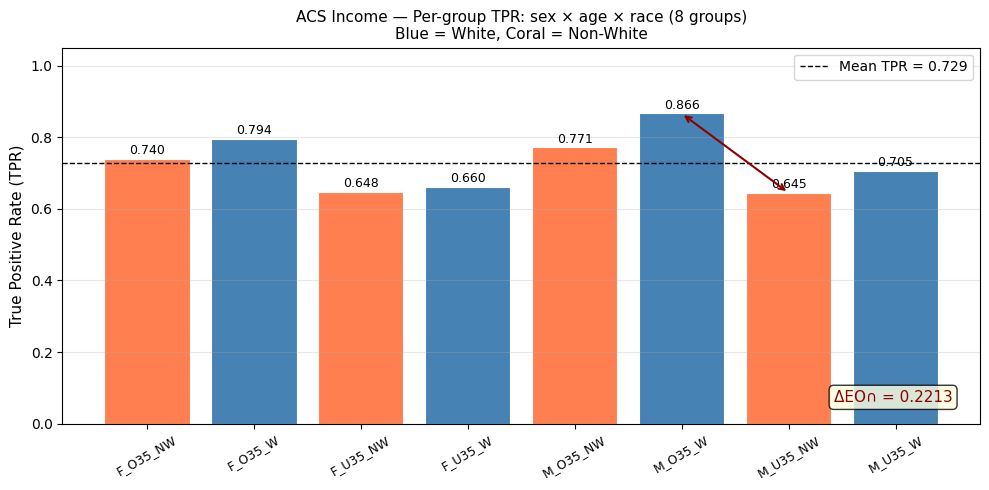

Saved: figures/fig_tpr_8group.pdf


In [34]:
# Figure — per-group TPR for all 8 groups; adding race raises ΔEO∩ by 21% (Goal 6, Section 5.6).
groups_sorted = sorted(subgroup_tprs.keys())
tpr_vals = [subgroup_tprs[g] for g in groups_sorted]

colours_8 = ['steelblue' if g.endswith('_W') else 'coral' for g in groups_sorted]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(groups_sorted, tpr_vals, color=colours_8, edgecolor='white', linewidth=0.8)
ax.axhline(np.mean(tpr_vals), color='black', linestyle='--', linewidth=1,
           label=f'Mean TPR = {np.mean(tpr_vals):.3f}')
for bar, v in zip(bars, tpr_vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.005, f'{v:.3f}',
            ha='center', va='bottom', fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel('True Positive Rate (TPR)', fontsize=11)
ax.set_title('ACS Income — Per-group TPR: sex × age × race (8 groups)\n'
             'Blue = White, Coral = Non-White', fontsize=11)
ax.tick_params(axis='x', rotation=30, labelsize=9)
ax.legend(fontsize=10); ax.grid(True, axis='y', alpha=0.3)

# Annotate ΔEO∩
deoi_8 = max(tpr_vals) - min(tpr_vals)
ax.annotate('', xy=(groups_sorted[tpr_vals.index(max(tpr_vals))], max(tpr_vals)),
            xytext=(groups_sorted[tpr_vals.index(min(tpr_vals))], min(tpr_vals)),
            arrowprops=dict(arrowstyle='<->', color='darkred', lw=1.5))
ax.text(0.97, 0.05, f'ΔEO∩ = {deoi_8:.4f}', transform=ax.transAxes,
        ha='right', va='bottom', fontsize=11, color='darkred',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('figures/fig_tpr_8group.pdf', bbox_inches='tight')
plt.show()
print('Saved: figures/fig_tpr_8group.pdf')


---
### Section 8 — Summary

The three-attribute analysis (Appendix, three-attribute section) confirms two dissertation conclusions:

1. **The audit gap grows with group granularity.** The two-attribute audit (sex × age)
   underestimates worst-case intersectional disparity by 21%. Any fixed set of attributes
   represents a lower bound on the true intersectional unfairness in the data.

2. **Post-processing scales.** A 80.8% reduction in ΔEO∩ at 0.63pp accuracy cost,
   achieved with 8 groups, confirms that per-group threshold calibration generalises
   beyond the four-group main study setting.

These results directly address **Research Goal 6** and are discussed in Section 5.6 and the
Discussion chapter of the dissertation.
